# Count each

In [1]:
v2_ccs = False
v3_ccs = True
n = 10
RESULTS_DIR = "all_results"

### Load

In [ ]:
from pathlib import Path
import json
import re

RESULTS_DIR = Path(RESULTS_DIR)
ARXIV_ID_PATTERN = re.compile(r'^\d{4}\.\d{4,5}(v\d+)?$')

arxiv_paths: dict[str, list[str]] = {}
hf_paths: dict[str, list[str]] = {}
tldr_paths: dict[str, list[str]] = {}
impAi_paths: dict[str, list[str]] = {}
unknown_keys: list[str] = []

for json_path in RESULTS_DIR.glob('*.json'):
    key = json_path.stem
    with json_path.open() as handle:
        payload = json.load(handle)

    path_value = None
    for value in payload.values():
        if isinstance(value, dict):
            if v3_ccs == False and 'path' in value:
                path_value = value['path']
                break
            elif v3_ccs:
                path_value = [*value["arch"], *value["prob"], *value["para"]]
                #path_value = value

    if path_value is None:
        continue

    if ARXIV_ID_PATTERN.fullmatch(key):
        arxiv_paths[key] = path_value
    elif "__" in key:#any(char.isalpha() for char in key):
        hf_paths[key] = path_value
    elif key.startswith("tldr_"):
        tldr_paths[key] = path_value
    elif key.startswith("impAi"):
        impAi_paths[key] = path_value

    else:
        unknown_keys.append(key)

print(f'Loaded \n\t{len(arxiv_paths)} arXiv paths,\n\t{len(hf_paths)} HF model paths,\n\t{len(tldr_paths)} tldr_ai paths and \n\t{len(impAi_paths)} import_AI paths')
if unknown_keys:
    print(f'WARNING: {len(unknown_keys)} filenames were not classified: {unknown_keys[:5]}')



Loaded 
	0 arXiv paths,
	0 HF model paths,
	320 tldr_ai paths and 
	378 import_AI paths


The other ones seem to be "philosophical/theoretical foundations of artificial intelligence"
this is of lenght 64, but when gtp predicts it it raises an error saying

!! BAD REQUEST ERROR!!
Error code: 400 - {'error': {'message': "Invalid 'response_format.json_schema.name': string too long. Expected a string with maximum length 64, but got a string with length 70 instead.", 'type': 'invalid_request_error', 'param': 'response_format.json_schema.name', 'code': 'string_above_max_length'}}
skipping paper and filling zeros in score
key: 2208.14037

### collect

In [ ]:
if v2_ccs:
    from metadata_schemas.acm_ccs_v2 import CCS_HIERARCHY
if v3_ccs:
    from metadata_schemas.acm_ccs_v3 import CCS_HIERARCHY

else:
    from metadata_schemas.acm_ccs import CCS_HIERARCHY


ccs_strings = str(CCS_HIERARCHY).split("'")[1::2]
ccs_counts_hf = {s:0 for s in ccs_strings}
ccs_counts_ax = ccs_counts_hf.copy()
ccs_counts_im = ccs_counts_hf.copy()
ccs_counts_tl = ccs_counts_hf.copy()

In [ ]:
for key in hf_paths:
    for term in hf_paths[key]:
        try:
            ccs_counts_hf[term] += 1
        except KeyError:
            print(key, hf_paths[key])

for key in arxiv_paths:
    for term in arxiv_paths[key]:
        try:
            ccs_counts_ax[term] += 1
        except KeyError:
            print(key, hf_paths[key])

for key in impAi_paths:
    for term in impAi_paths[key]:
        try:
            ccs_counts_im[term] += 1
        except KeyError:
            print(key, impAi_paths[key])

for key in tldr_paths:
    for term in tldr_paths[key]:
        try:
            ccs_counts_tl[term] += 1
        except KeyError:
            print(key, tldr_paths[key])



In [ ]:
print("Hf\tArxiv\n")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if axc < hfc:
                print(hfc, "\t", axc, "\t",term)

print("")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if hfc < axc:
                print(hfc, "\t", axc, "\t",term)


print("Hf\tArxiv\ttldr\timpAi\n")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    imc, tlc = ccs_counts_tl[term], ccs_counts_ax[term]

    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if axc < hfc:
                print(hfc, "\t", axc, "\t",term)

print("")
for term in ccs_strings:
    hfc, axc = ccs_counts_hf[term], ccs_counts_ax[term]
    if hfc+axc>5:
        if min(hfc, axc) / max(hfc, axc) < 0.5:
            if hfc < axc:
                print(hfc, "\t", axc, "\t",term)

Hf	Arxiv

5 	 2 	 Decision trees
46 	 20 	 Feed-forward networks
8 	 1 	 Autoencoders
5 	 2 	 Vanilla RNN
269 	 123 	 Transformer architectures
57 	 2 	 Decoder-only transformers
86 	 7 	 Encoder-only transformers
82 	 7 	 BERT
274 	 100 	 Natural language processing
7 	 2 	 Question answering
207 	 41 	 Generation and interaction
22 	 4 	 Machine translation
40 	 19 	 Summarization
67 	 8 	 Dialogue systems
44 	 10 	 Human-AI co-writing
34 	 0 	 Speech recognition and synthesis
14 	 2 	 Creative AI applications
8 	 1 	 Sequence labeling
24 	 11 	 Density estimation
155 	 56 	 Model adaptation / fine-tuning
32 	 2 	 Full-parameter fine-tuning
37 	 12 	 Task-specific fine-tuning
53 	 16 	 Parameter-efficient tuning
11 	 4 	 Adapter-based tuning
38 	 9 	 Low-rank adaptation (LoRA)
51 	 8 	 Model-free RL

4 	 13 	 3D CNNs
2 	 8 	 Convolutional autoencoders
2 	 9 	 Sparse attention transformers
2 	 7 	 Long-context transformers
4 	 18 	 Multimodal transformers
2 	 15 	 Vision-language tran

# Find time stamps

In [6]:
from dataset_loader import Arxiv_HF_datasets
ahd = Arxiv_HF_datasets()
ahd.prepare()
hf_df, arx_df = ahd.sample_subsets(n)

/home/sondre/profile/llmdap/profiler/dataset_loader.py:448: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  self.arx = self.arx[self.arx["bin"]>=bin_range[0]][self.arx["bin"]<=bin_range[1]]


In [7]:
hf_df = hf_df.set_index("modelId")

# Compile to single results files

In [8]:
hf_df = hf_df.drop(["card", "tags", "pipeline_tag", "bin"], axis=1)
hf_df["predicted_tag"] = ""

In [9]:
arx_df = arx_df.drop(["title", "abstract", "authors_parsed", "bin"], axis=1)
arx_df["predicted_tag"] = ""

In [10]:
for modelid in hf_df.index:
    try:
        hf_df.loc[modelid, "predicted_tag"]= str(hf_paths[modelid.replace("/","__")])
    except:
        print(modelid)
        hf_df.loc[modelid, "predicted_tag"]= str(["Computing methodologies","Artificial intelligence","Philosophical/theoretical foundations of artificial intelligence"])

In [11]:
for paperid in arx_df.index:
    try:
        arx_df.loc[paperid, "predicted_tag"]= str(arxiv_paths[paperid])
    except KeyError:
        print(paperid)
        arx_df.loc[paperid, "predicted_tag"]= str(["Computing methodologies","Artificial intelligence","Philosophical/theoretical foundations of artificial intelligence"])

In [12]:
hf_df.to_csv("hf_trends.csv.bz2")
arx_df.to_csv("arxiv_trends.csv.bz2")

# plots

In [13]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
if v2_ccs:
    from metadata_schemas.acm_ccs_v2 import CCS_HIERARCHY
if v3_ccs:
    from metadata_schemas.acm_ccs_v3 import CCS_HIERARCHY

else:
    from metadata_schemas.acm_ccs import CCS_HIERARCHY

ccs_strings = str(CCS_HIERARCHY).split("'")[1::2]


In [14]:
hf_df=pd.read_csv("hf_trends.csv.bz2", index_col=0)
arx_df=pd.read_csv("arxiv_trends.csv.bz2", index_col=0)

hf_df["createdAt"] = pd.to_datetime(hf_df["createdAt"])
arx_df["submission_date"] = pd.to_datetime(arx_df["submission_date"])


In [15]:
def plot_term(term, min_total=30):
    hf_dates = hf_df[hf_df["predicted_tag"].str.contains("'"+term+"'")]["createdAt"]
    arx_dates = arx_df[arx_df["predicted_tag"].str.contains("'"+term+"'")]["submission_date"]

    if len(arx_dates)+len(hf_dates)<min_total:
        return
    if len(arx_dates):
        plt.hist(arx_dates, bins=20, label="arx:"+str(len(arx_dates)), color='#1f77b4')
    if len(hf_dates):
        plt.hist(hf_dates, bins=20, alpha=0.6, label="HF:"+str(len(hf_dates)), color='#ff7f0e')
    plt.title(term)
    plt.legend()
    plt.show()



In [16]:
def plot_term_smooth(term, freq='W', window=9, sigma=2.0, min_total=30):
    """Plot smoothed submission trends for a single CCS term."""
    hf_dates = hf_df[hf_df["predicted_tag"].str.contains("\'" + term + "\'")]["createdAt"]
    arx_dates = arx_df[arx_df["predicted_tag"].str.contains("\'" + term + "\'")]["submission_date"]

    total_observations = len(hf_dates) + len(arx_dates)
    if total_observations < min_total:
        return

    def _counts_with_smoothing(dates):
        if dates.empty:
            return (pd.Series(dtype=float), pd.Series(dtype=float))
        ts = pd.Series(1, index=dates.sort_values())
        counts = ts.resample(freq).sum().fillna(0)

        window_size = max(int(window), 1)
        if window_size % 2 == 0:
            window_size += 1
        radius = window_size // 2
        offsets = np.arange(-radius, radius + 1, dtype=float)
        bandwidth = max(float(sigma), 1e-3)
        kernel = np.exp(-0.5 * (offsets / bandwidth) ** 2)
        kernel /= kernel.sum()

        values = counts.values.astype(float)
        padded = np.pad(values, (radius, radius), mode='edge')
        smoothed_values = np.convolve(padded, kernel, mode='valid')
        smoothed = pd.Series(smoothed_values, index=counts.index)
        return counts, smoothed

    hf_counts, hf_smoothed = _counts_with_smoothing(hf_dates)
    arx_counts, arx_smoothed = _counts_with_smoothing(arx_dates)

    if hf_smoothed.empty and arx_smoothed.empty:
        return

    freq_labels = {'D': 'day', 'W': 'week', 'M': 'month', 'Q': 'quarter'}
    cadence = freq_labels.get(freq, freq)

    fig, ax = plt.subplots(figsize=(9, 4))
    if not arx_smoothed.empty:
        ax.plot(arx_smoothed.index, arx_smoothed.values, label='arXiv (smoothed)', color='#1f77b4')
        ax.scatter(arx_counts.index, arx_counts.values, label='_nolegend_', color='#1f77b4', alpha=0.25, s=15)
    if not hf_smoothed.empty:
        ax.plot(hf_smoothed.index, hf_smoothed.values, label='HF models (smoothed)', color='#ff7f0e')
        ax.scatter(hf_counts.index, hf_counts.values, label='_nolegend_', color='#ff7f0e', alpha=0.25, s=15)

    ax.set_title(term)
    ax.set_ylabel(f'Entries per {cadence}')
    ax.legend()
    ax.grid(alpha=0.2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


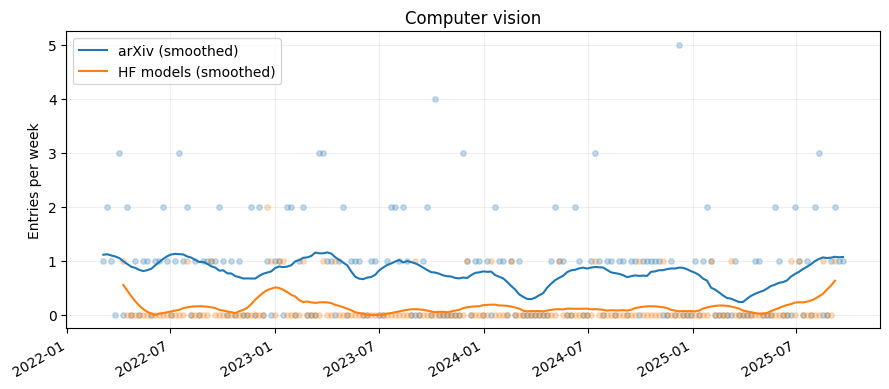

In [17]:
plot_term_smooth(term = "Computer vision", sigma=4, window=14)

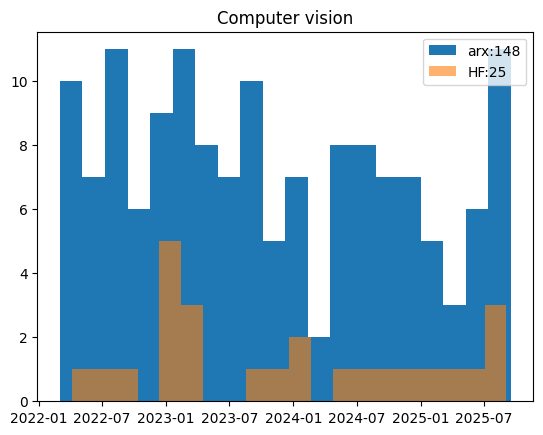

In [18]:
plot_term(term = "Computer vision")

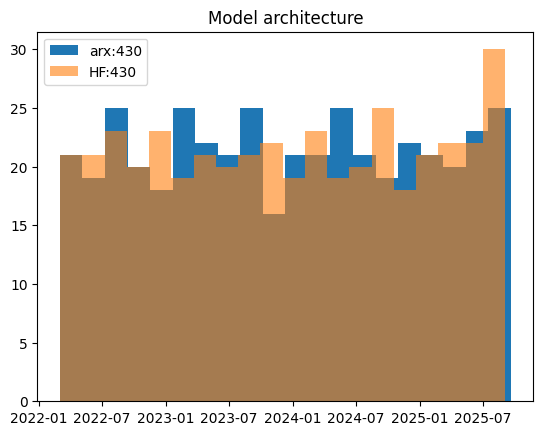

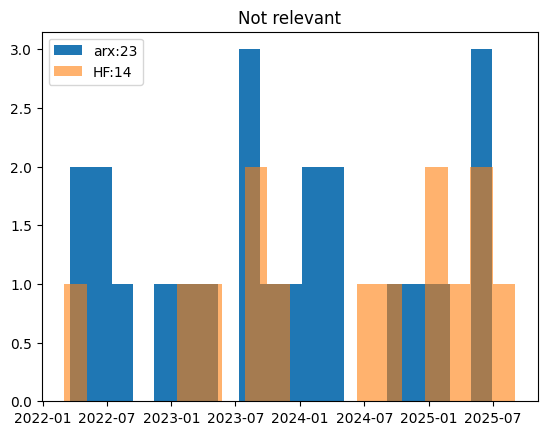

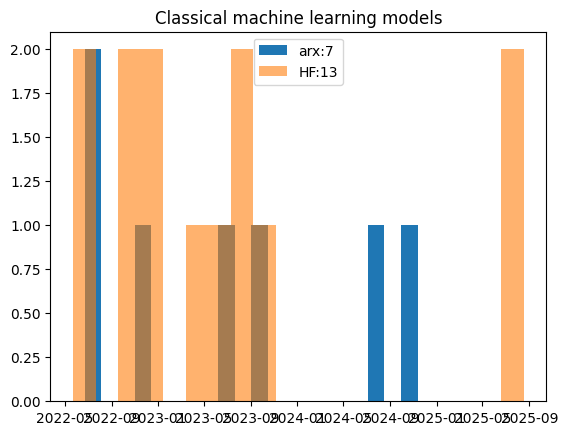

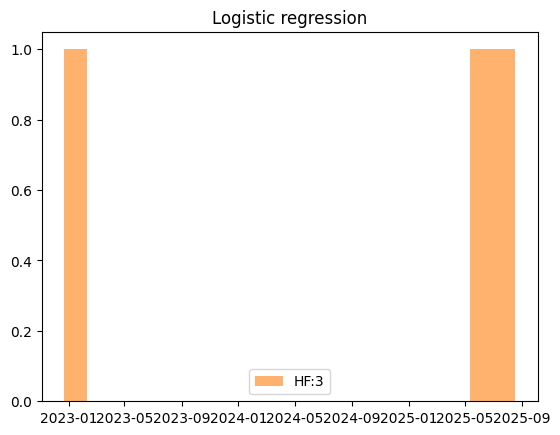

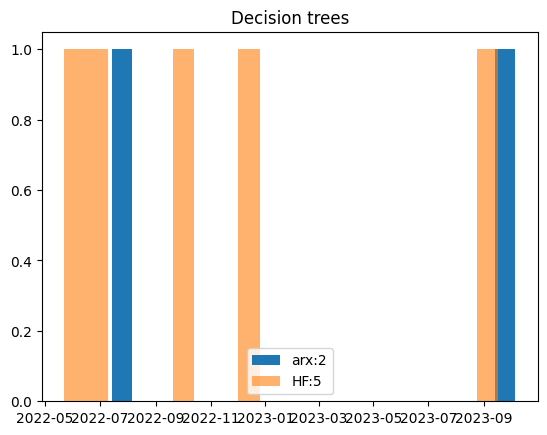

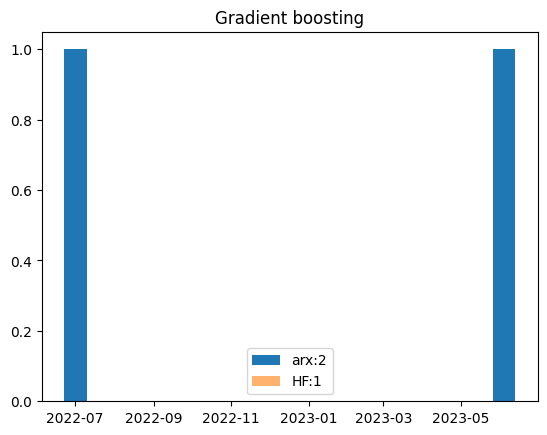

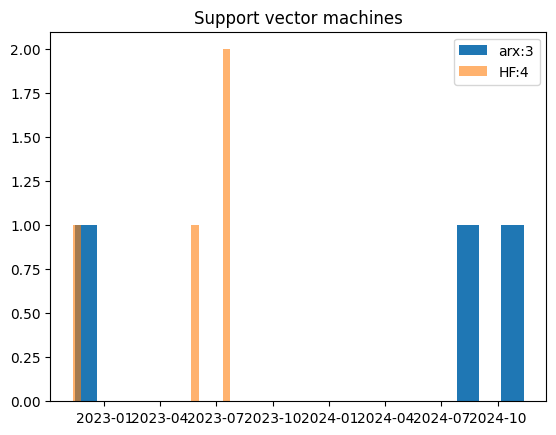

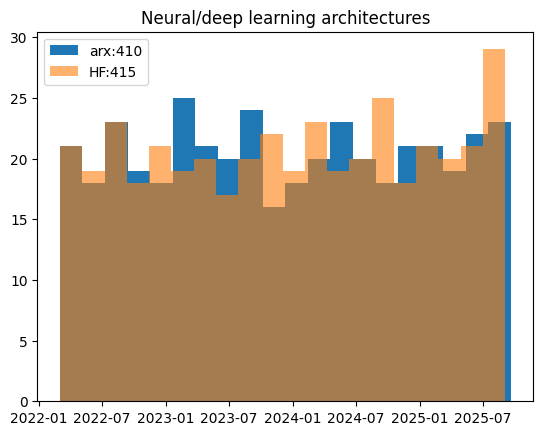

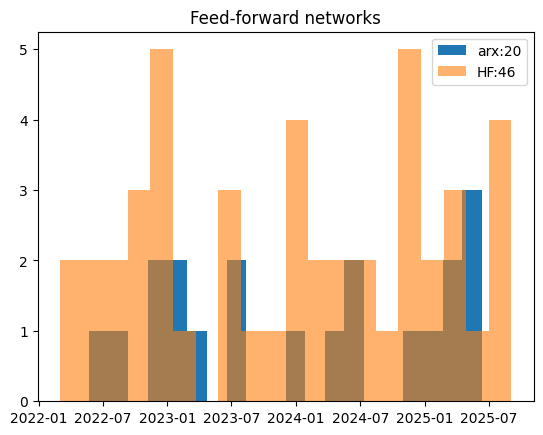

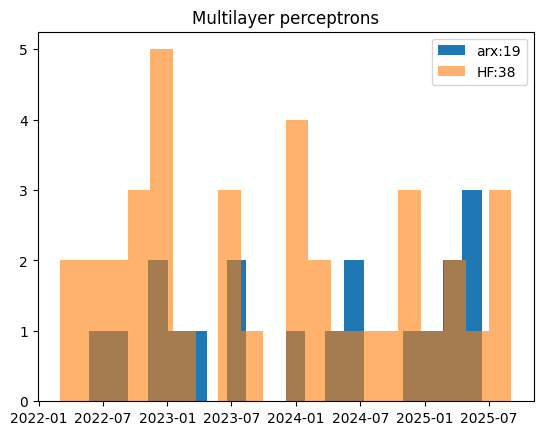

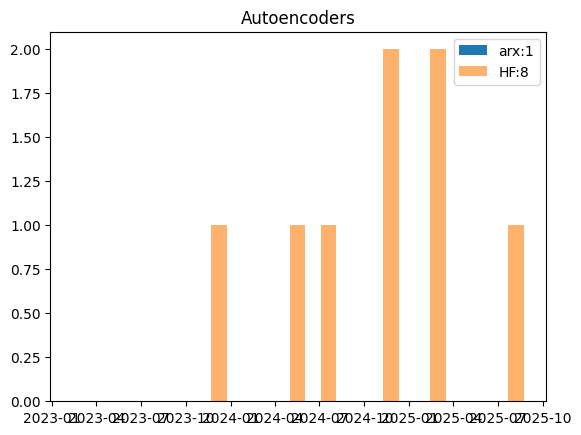

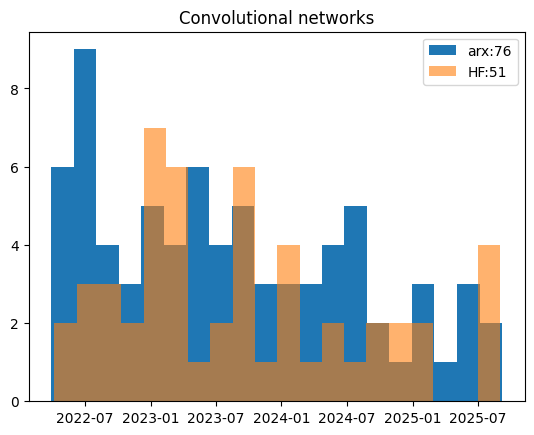

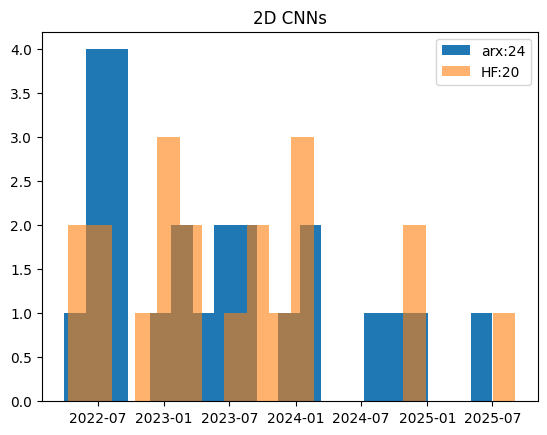

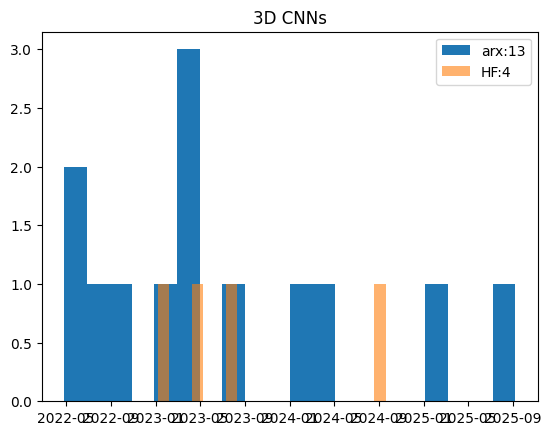

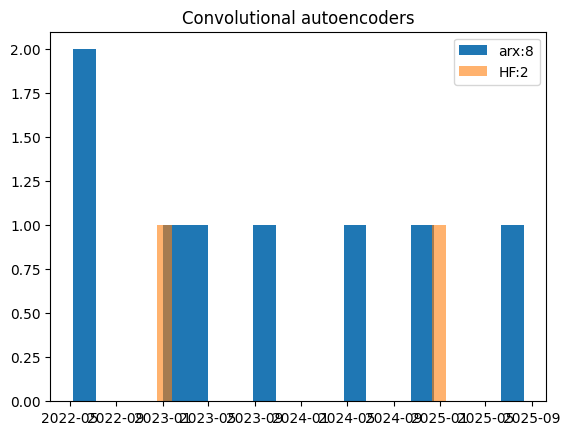

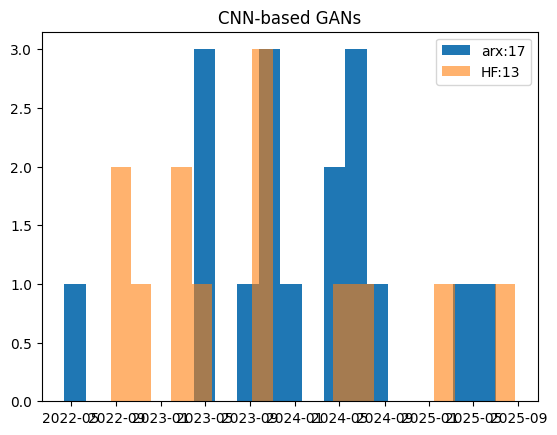

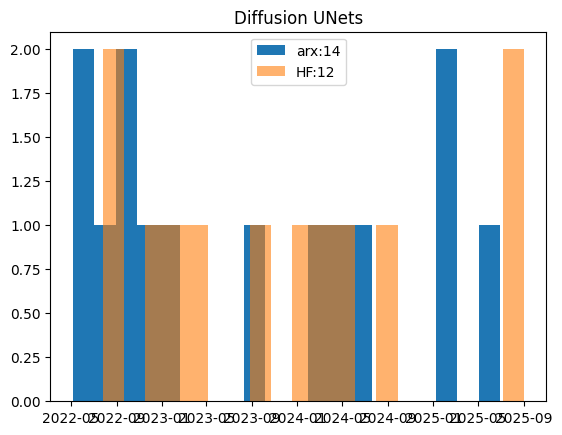

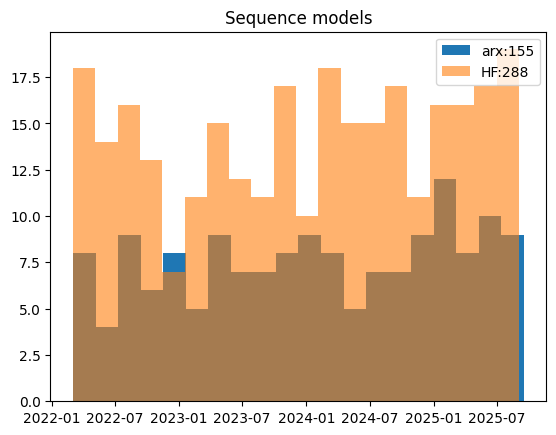

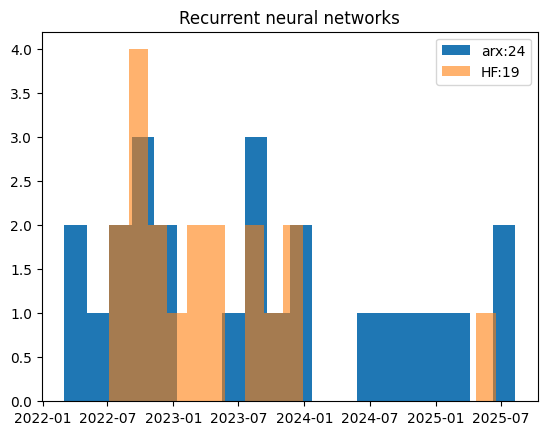

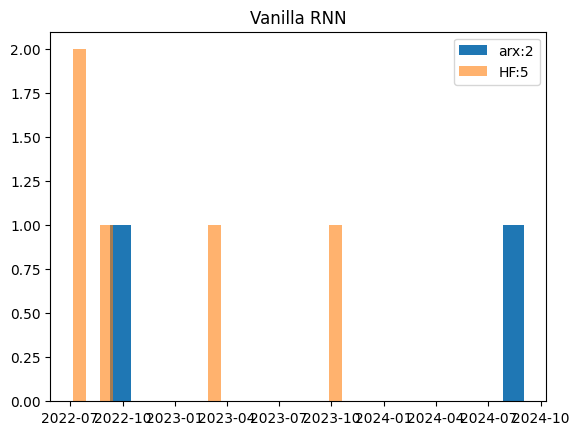

/tmp/ipykernel_1854049/2664932745.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hf_dates = hf_df[hf_df["predicted_tag"].str.contains("'"+term+"'")]["createdAt"]
/tmp/ipykernel_1854049/2664932745.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  arx_dates = arx_df[arx_df["predicted_tag"].str.contains("'"+term+"'")]["submission_date"]


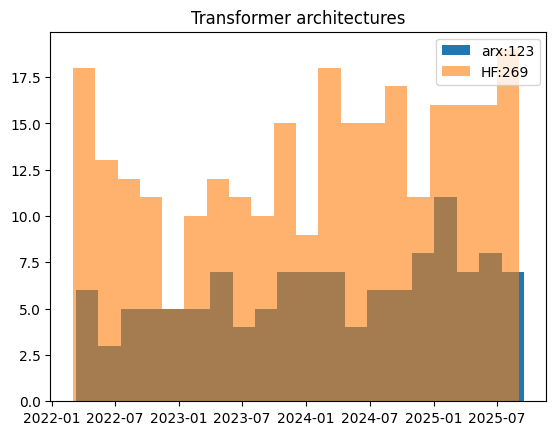

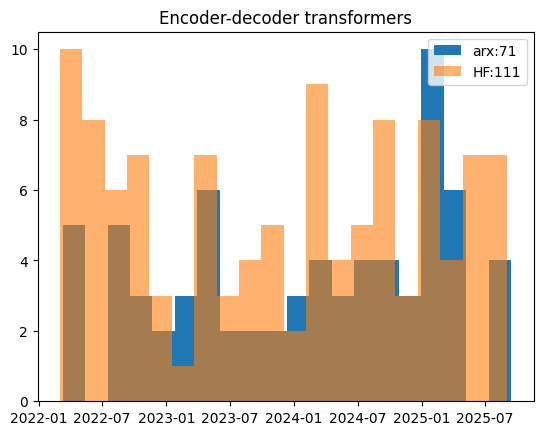

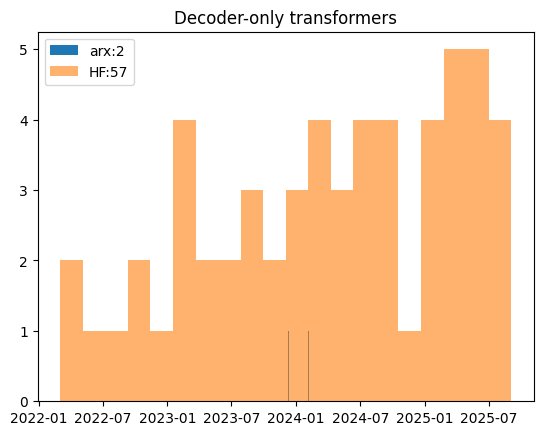

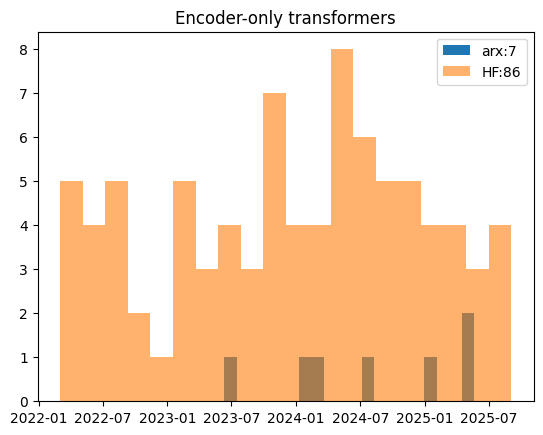

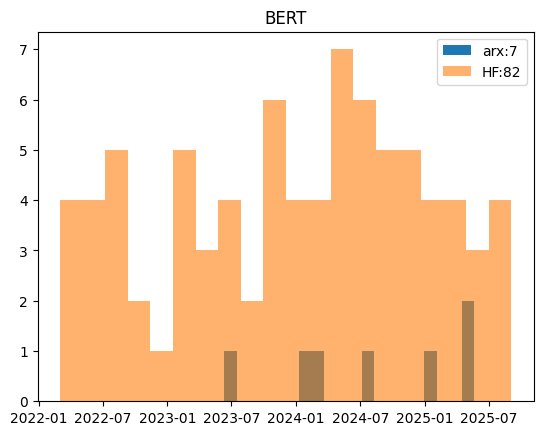

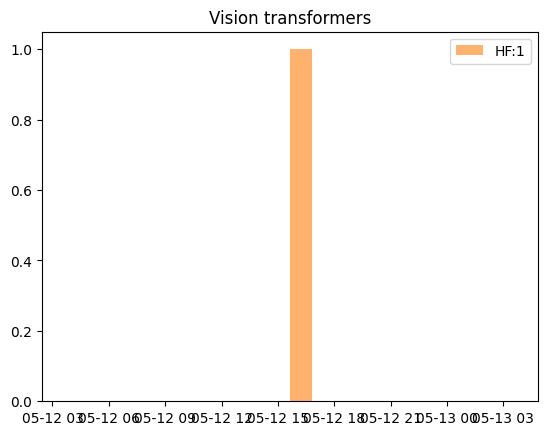

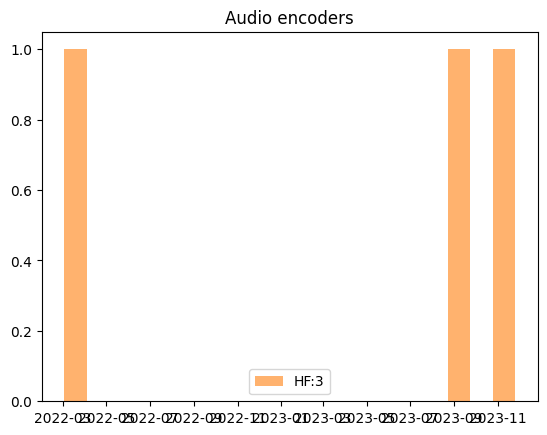

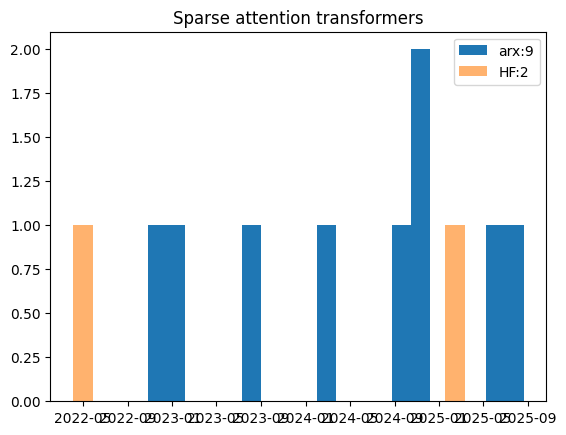

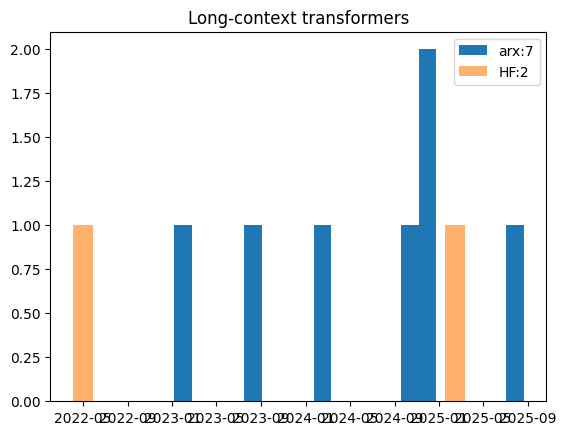

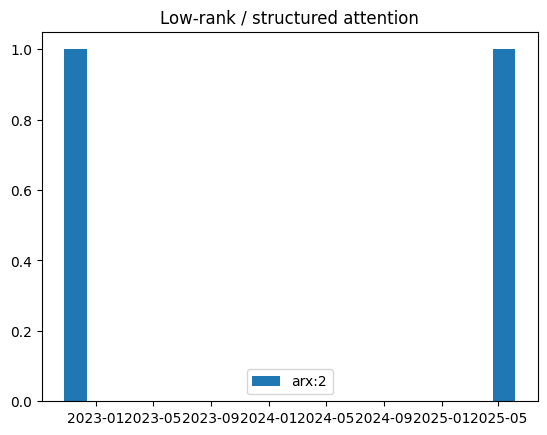

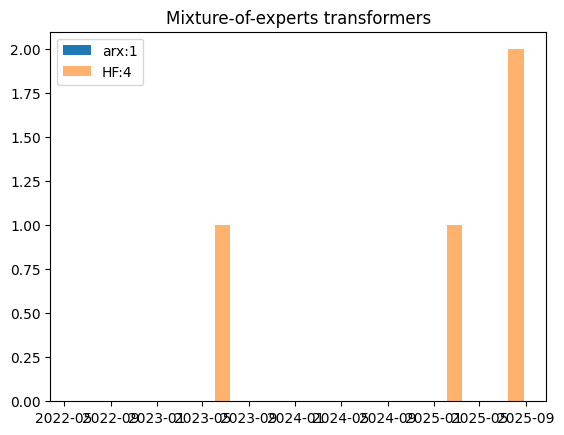

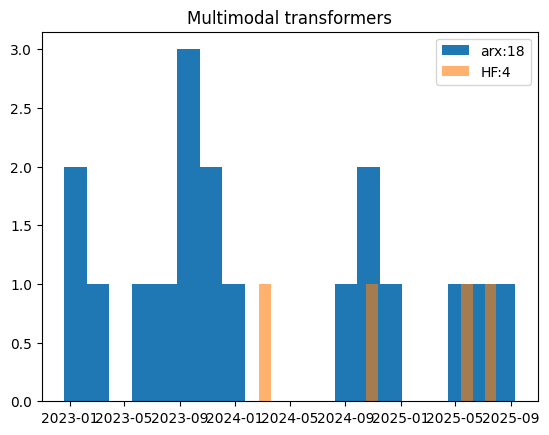

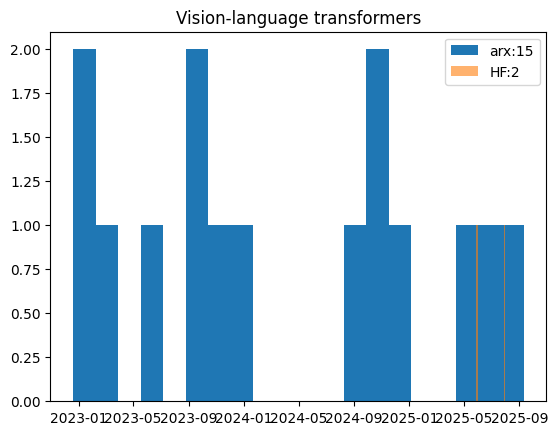

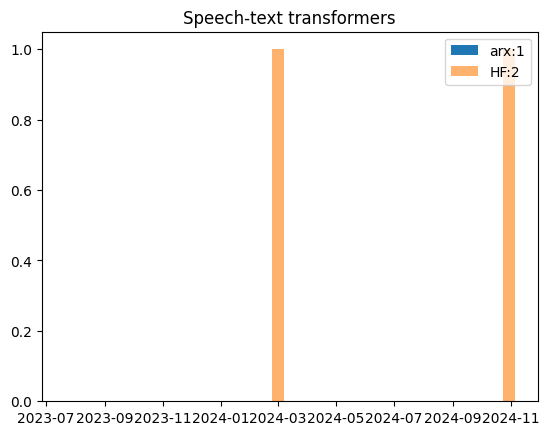

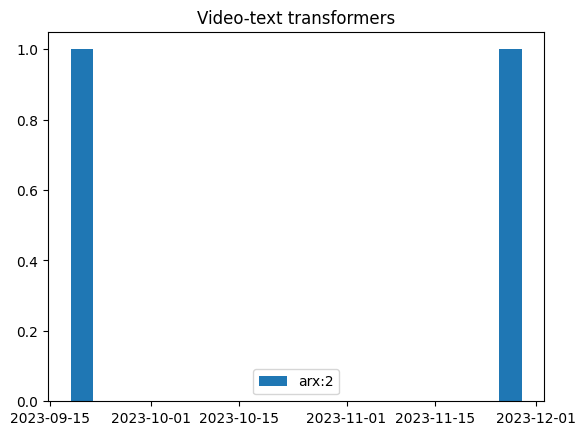

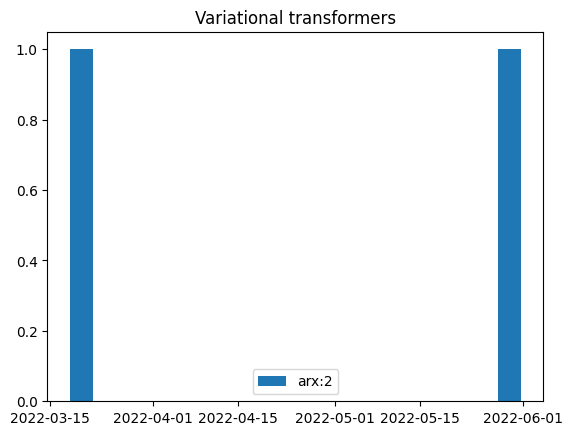

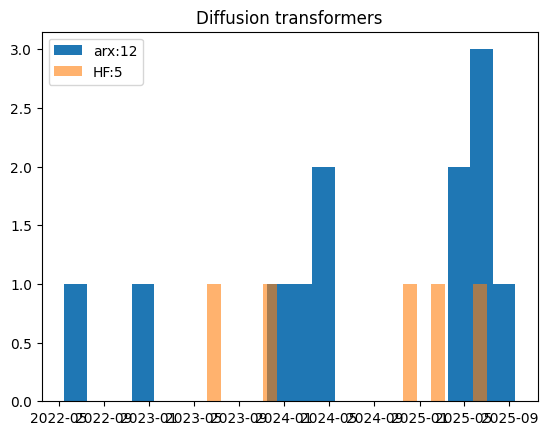

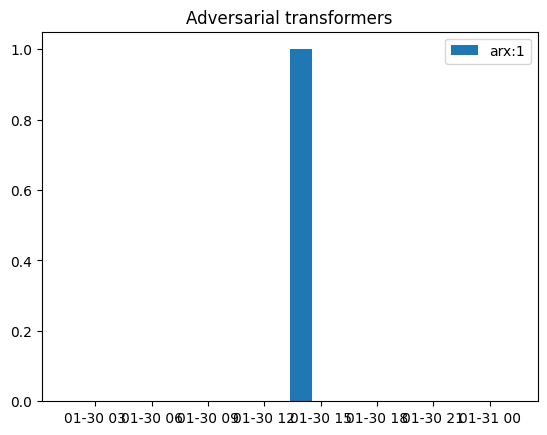

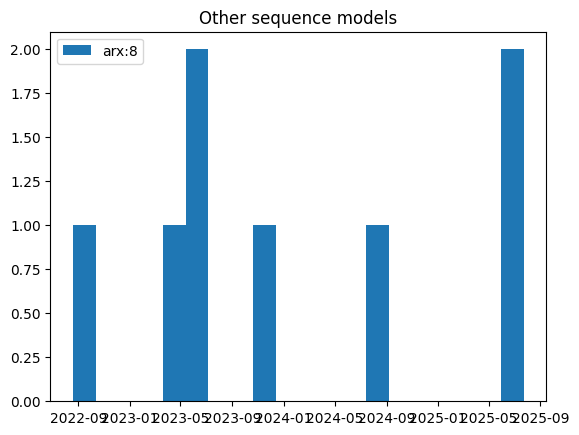

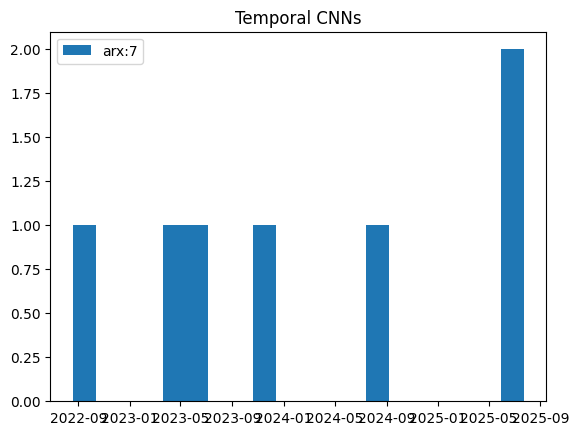

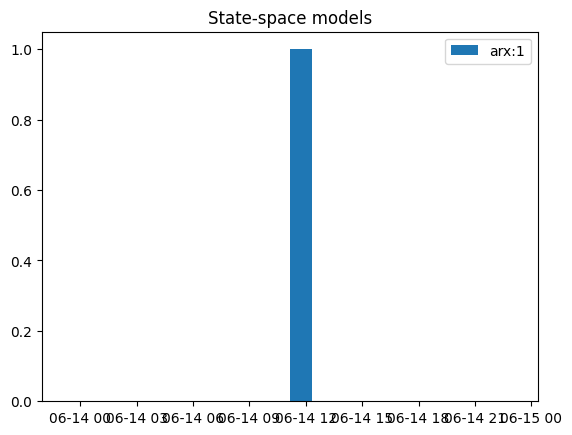

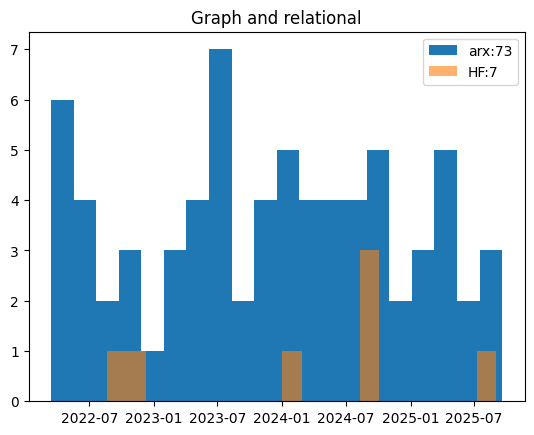

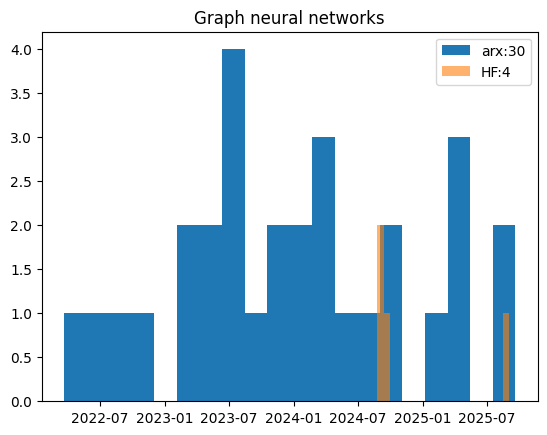

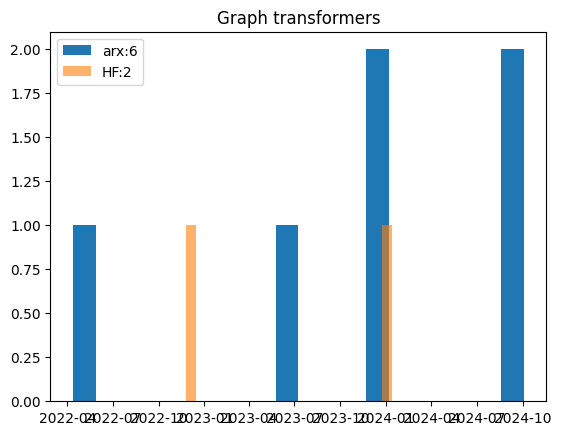

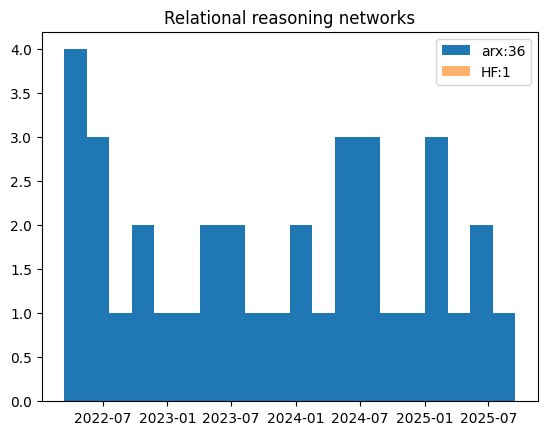

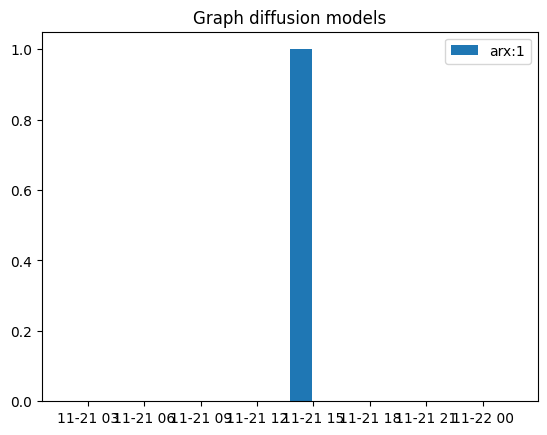

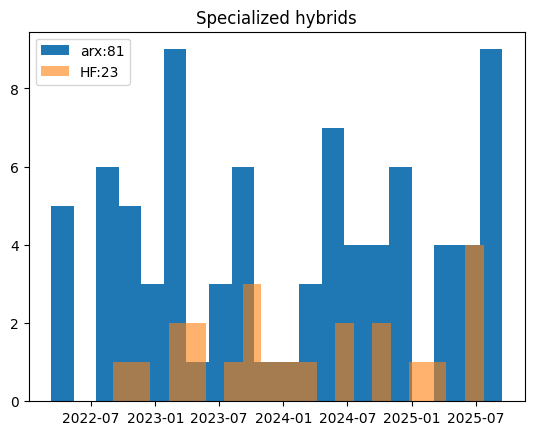

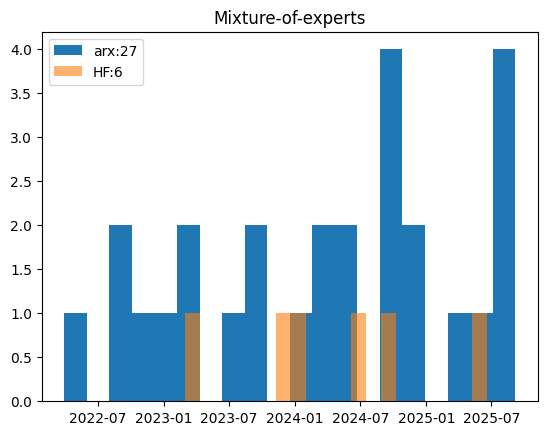

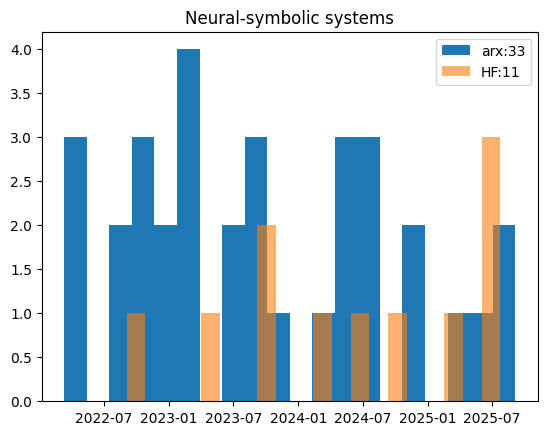

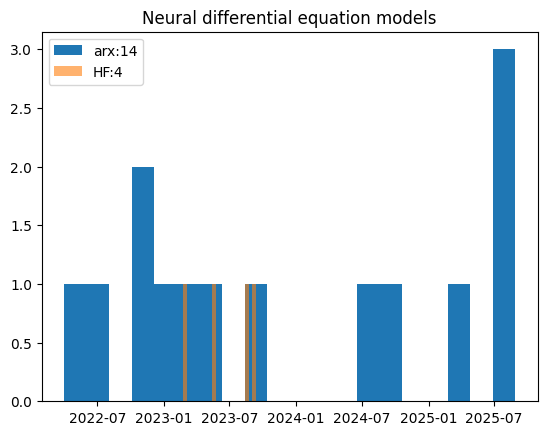

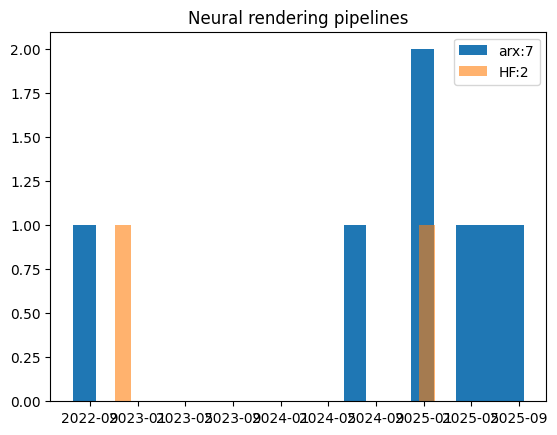

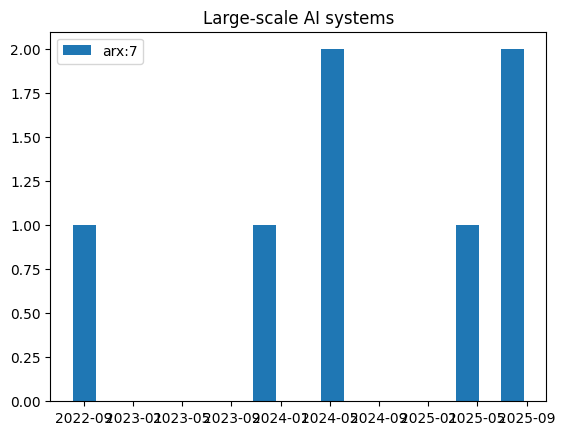

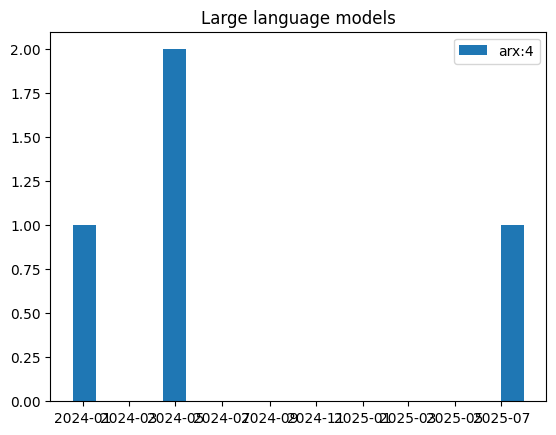

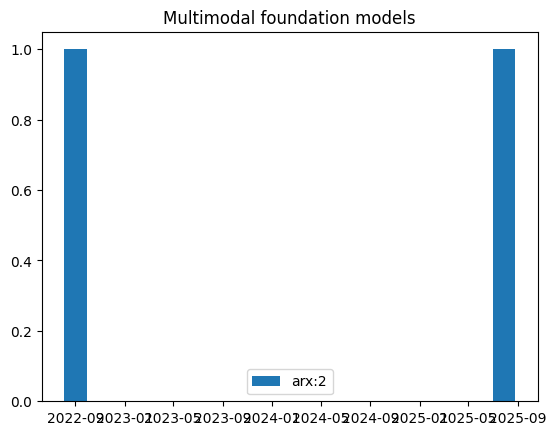

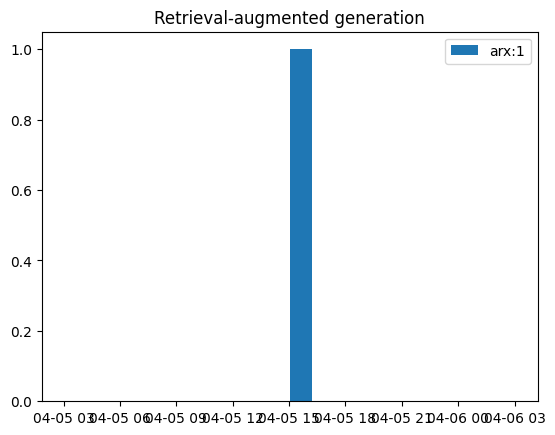

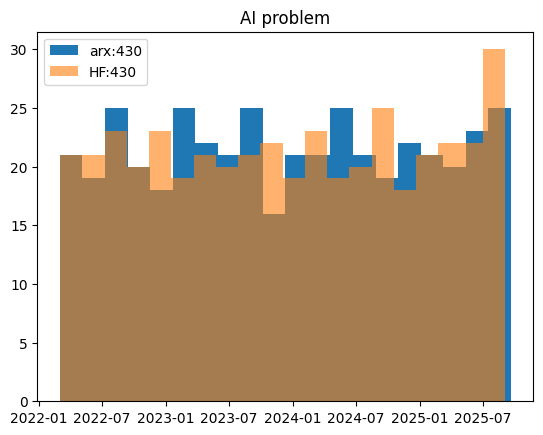

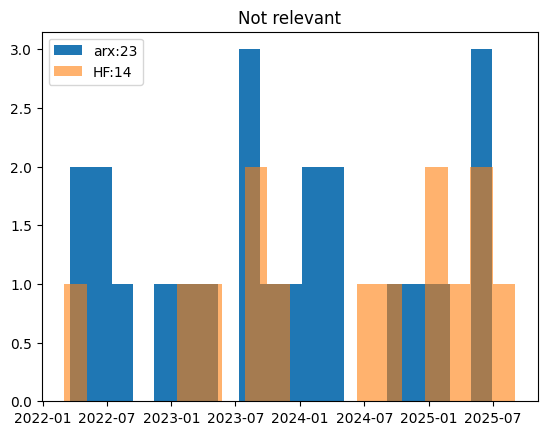

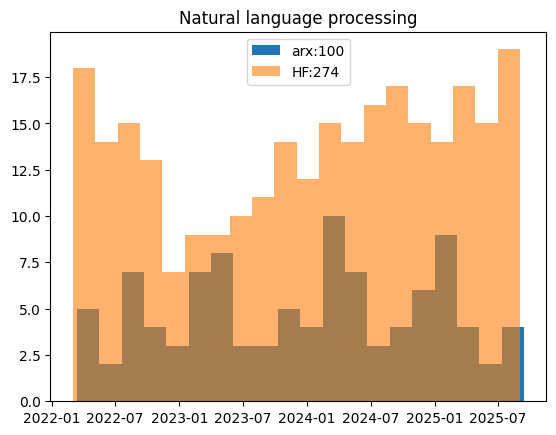

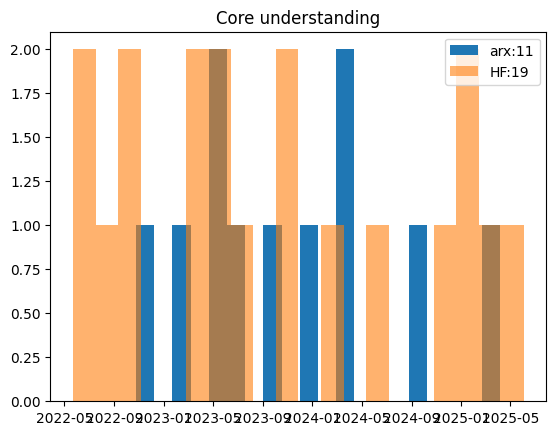

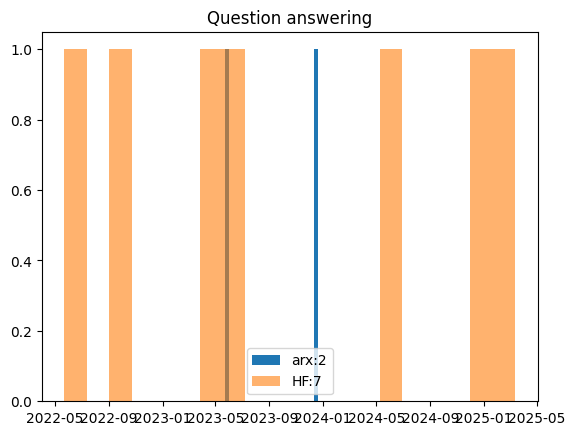

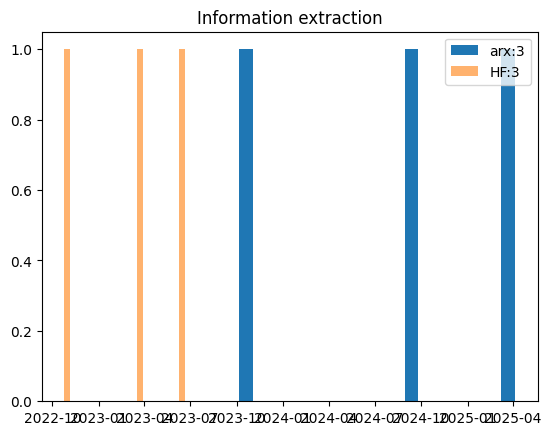

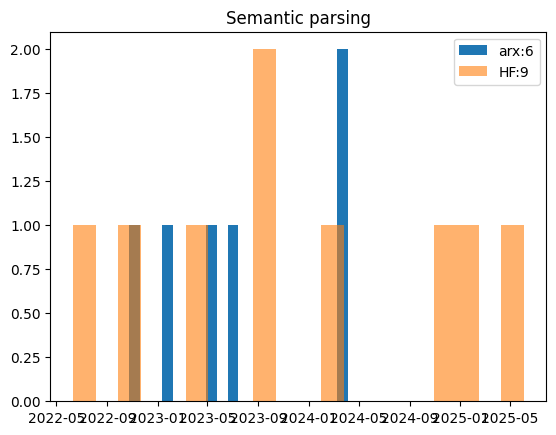

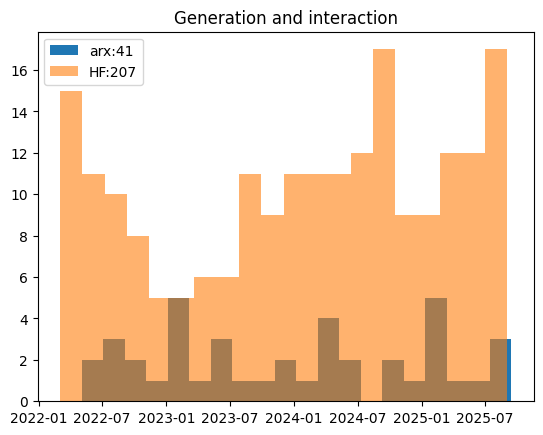

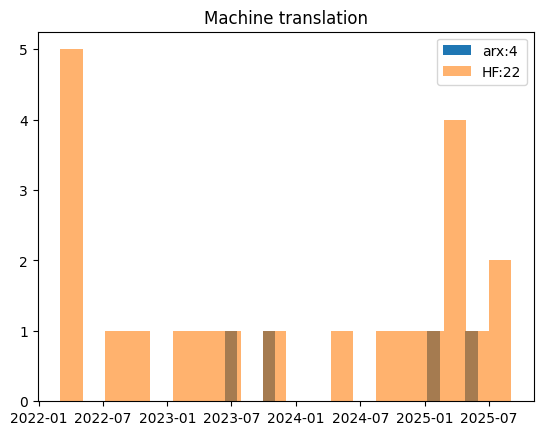

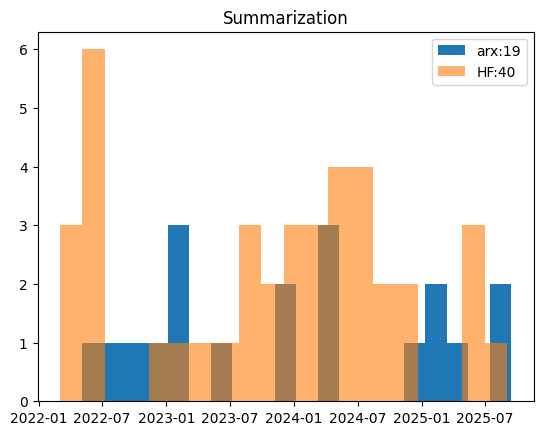

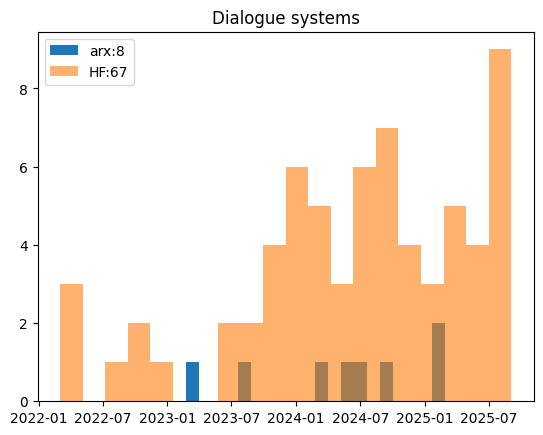

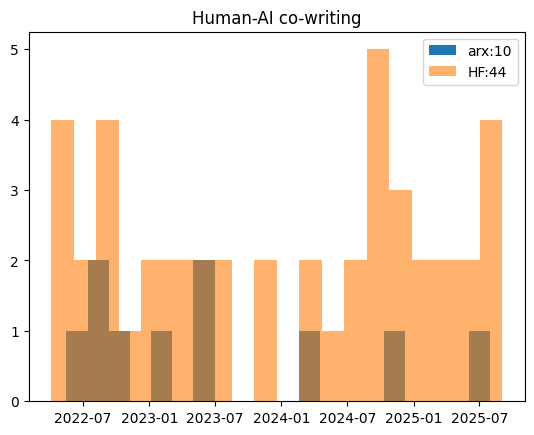

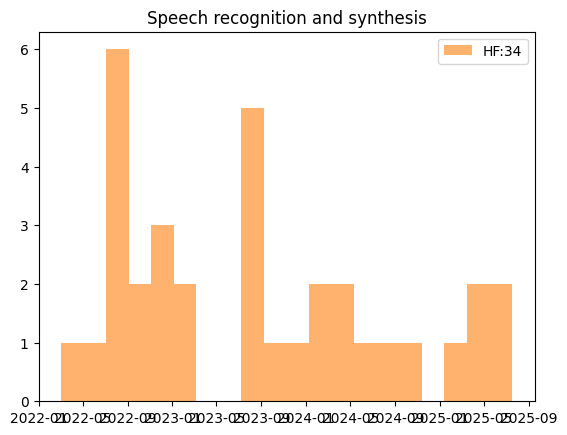

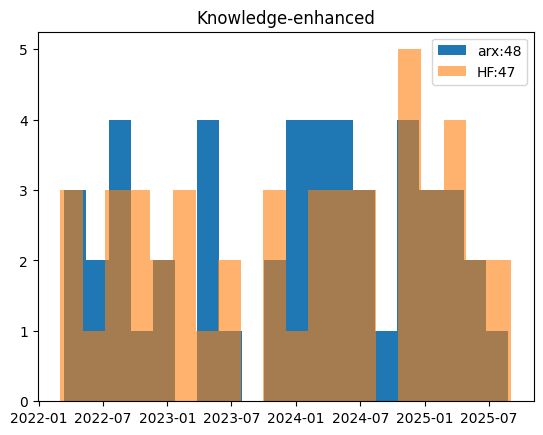

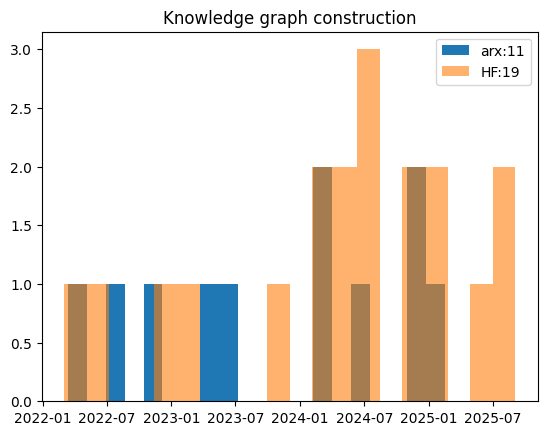

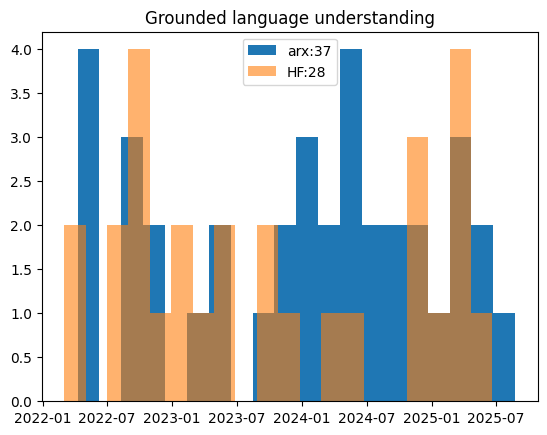

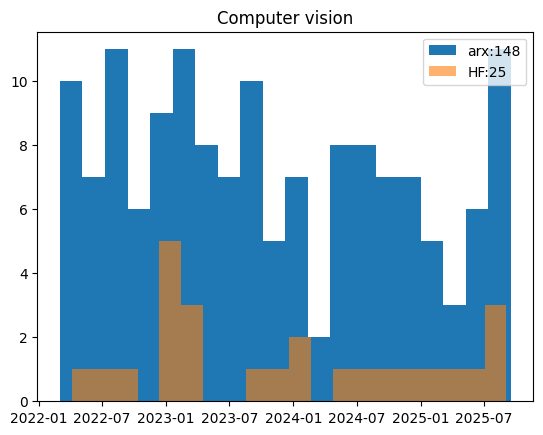

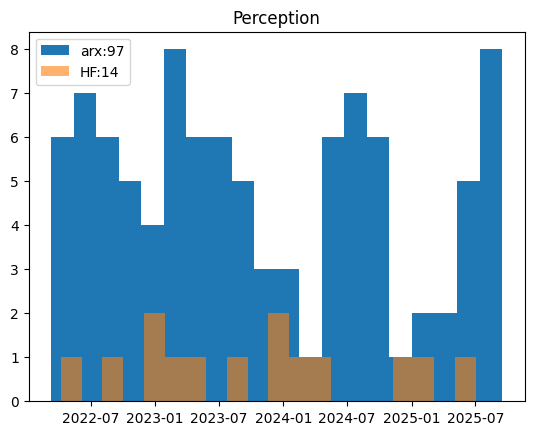

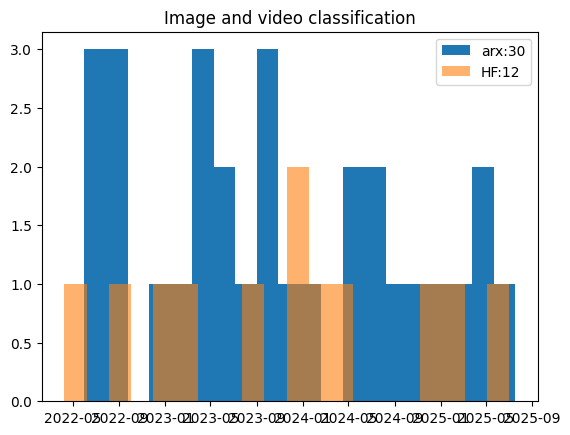

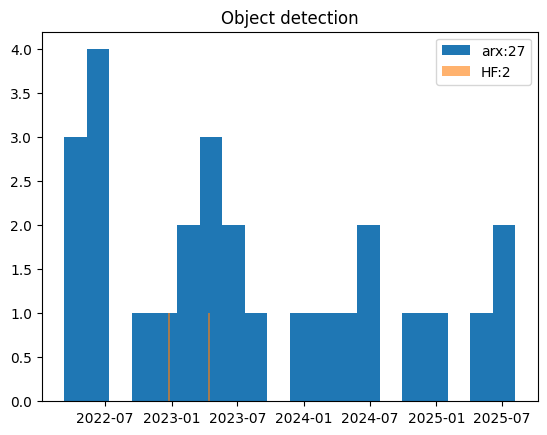

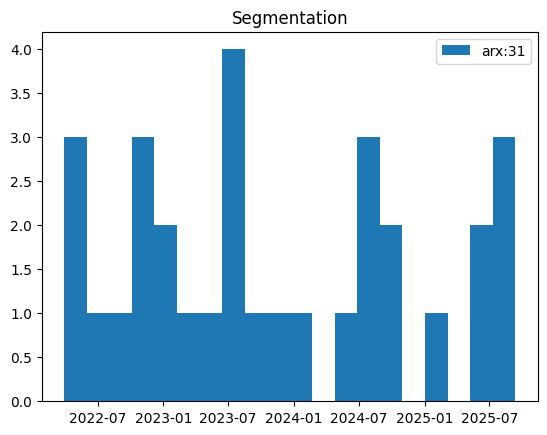

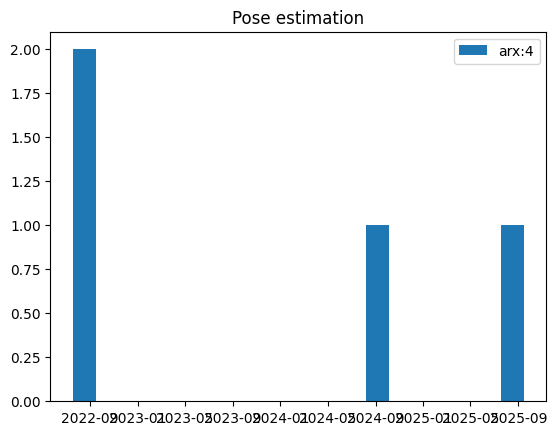

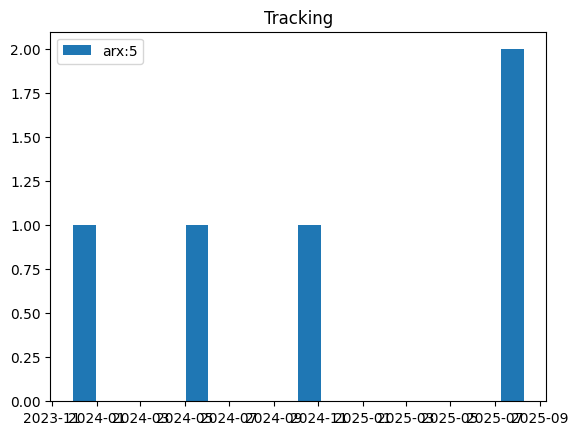

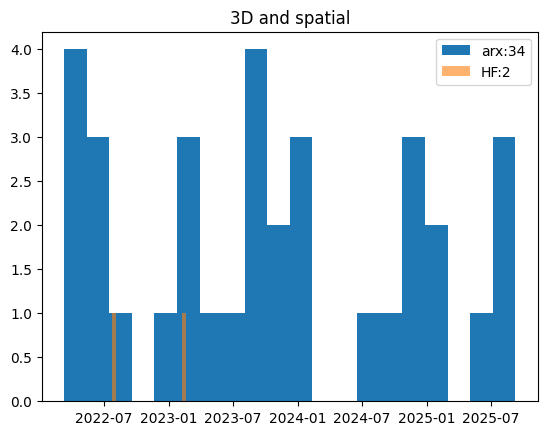

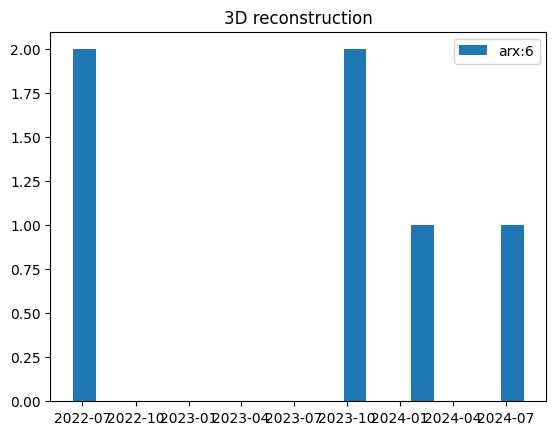

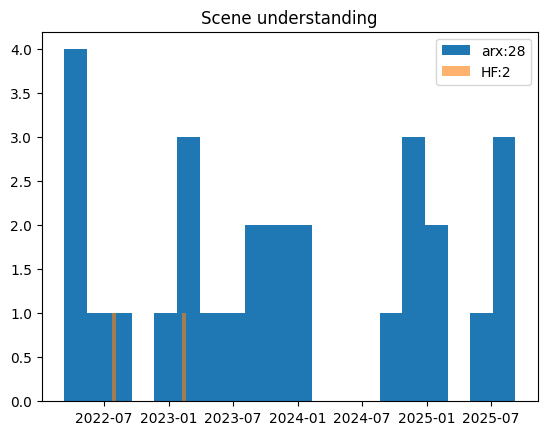

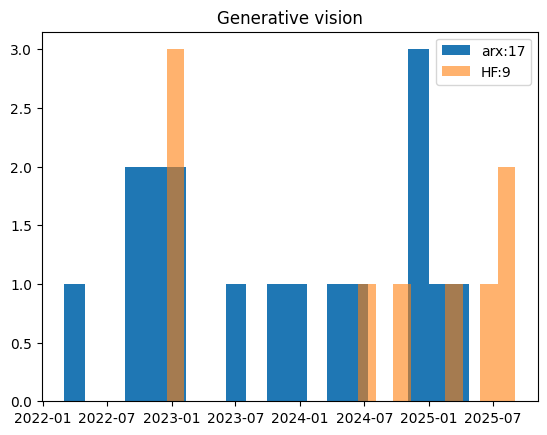

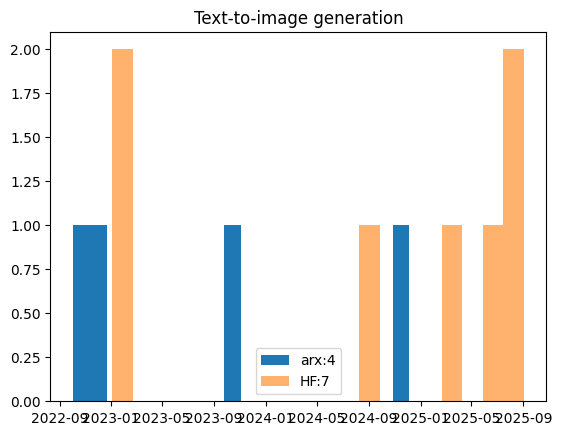

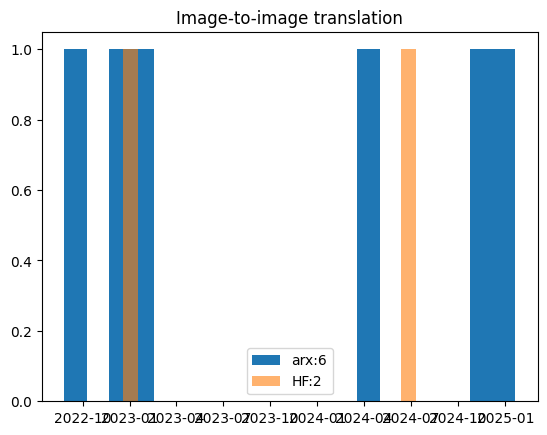

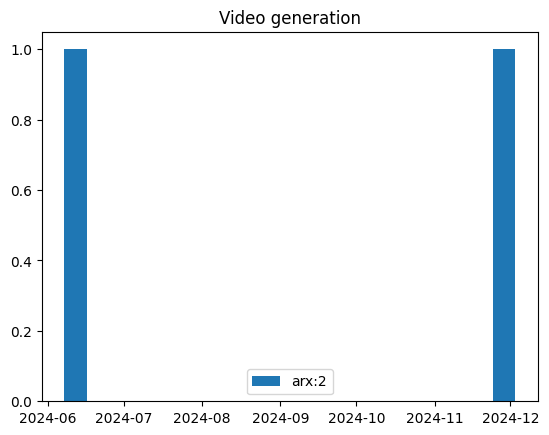

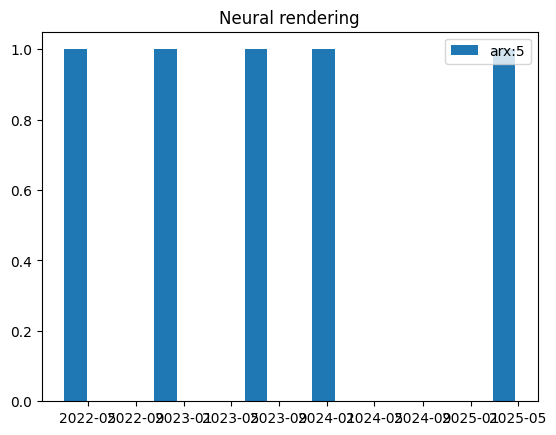

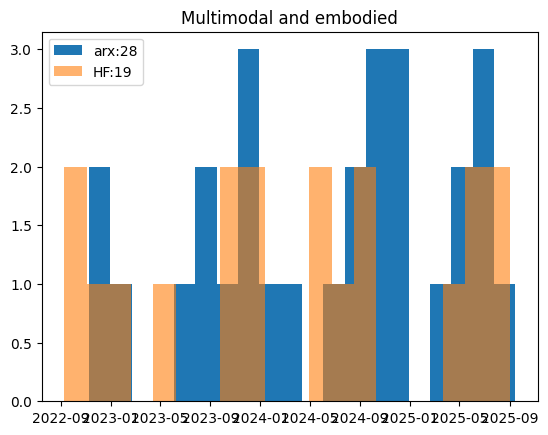

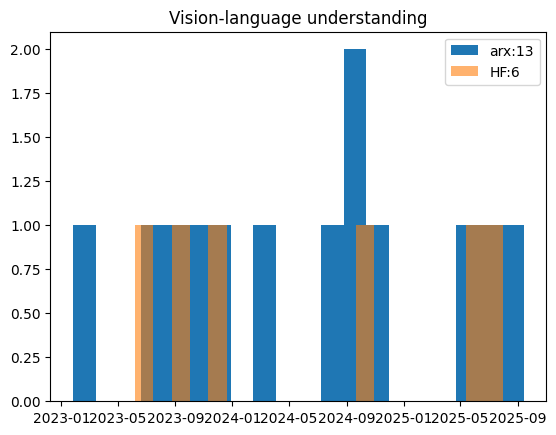

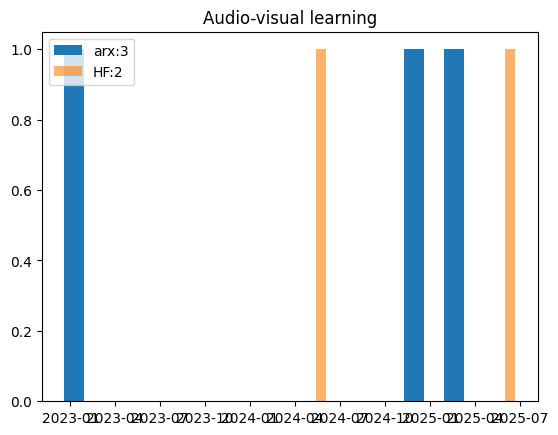

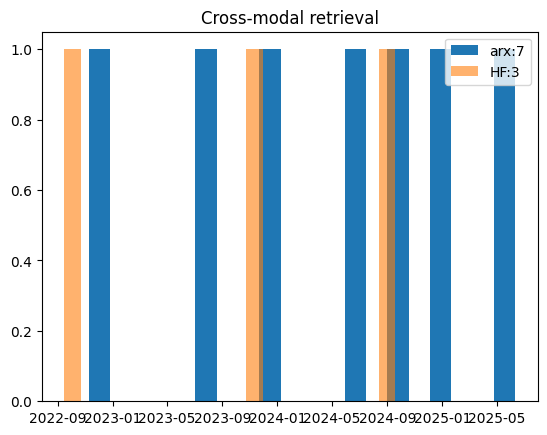

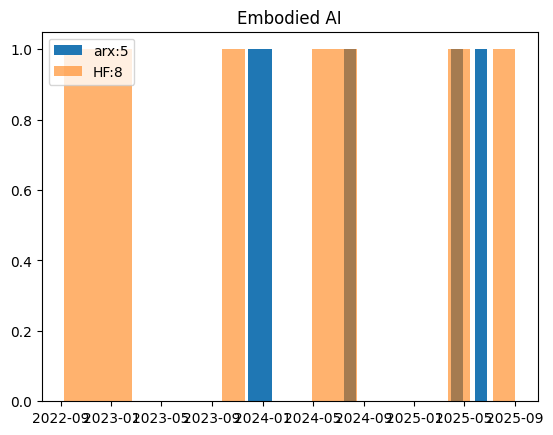

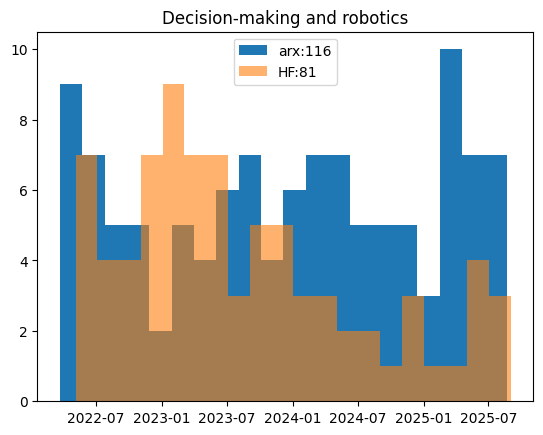

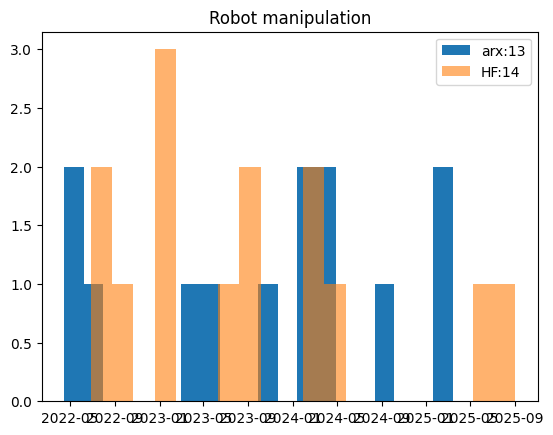

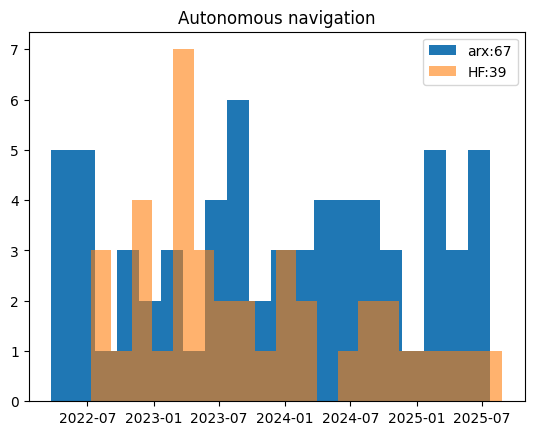

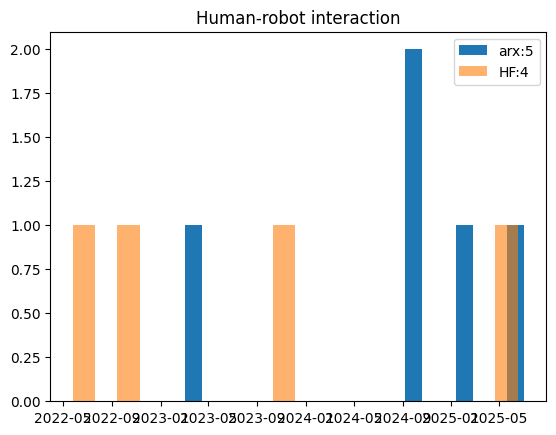

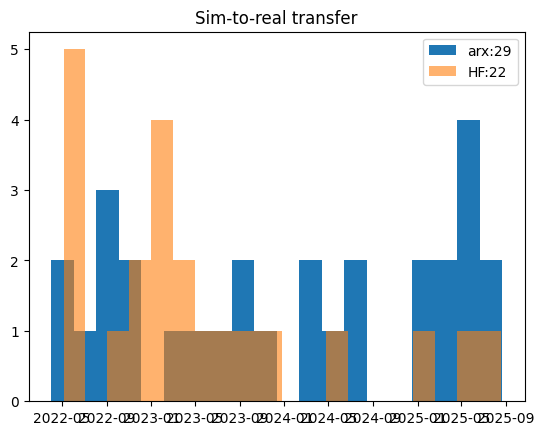

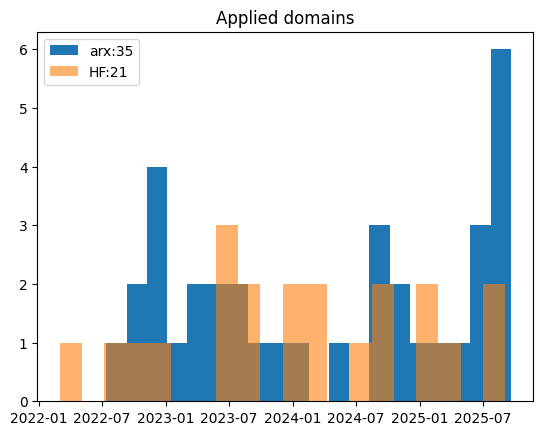

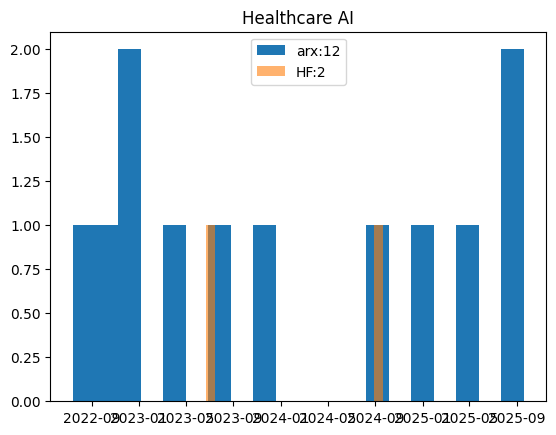

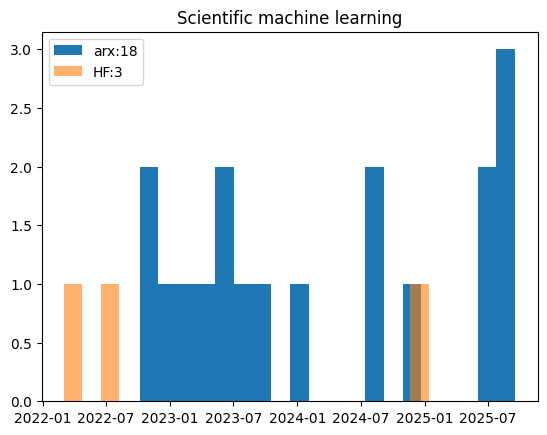

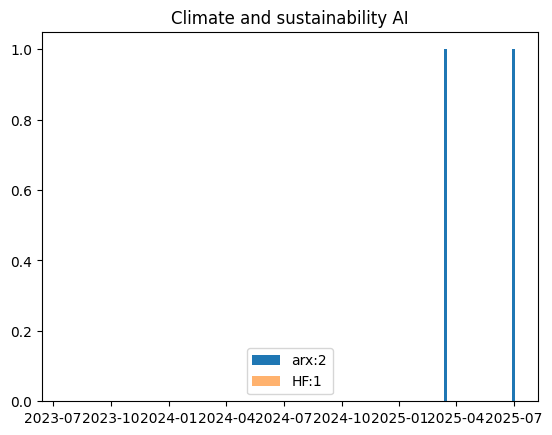

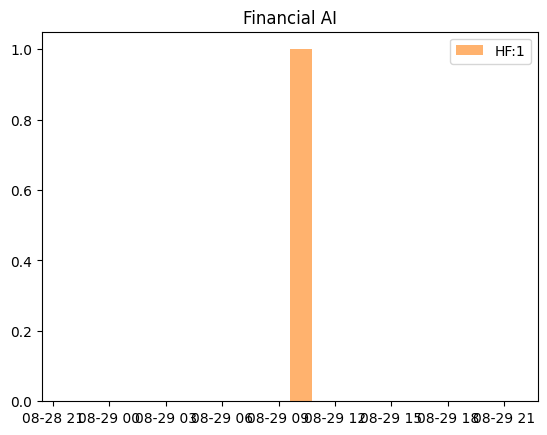

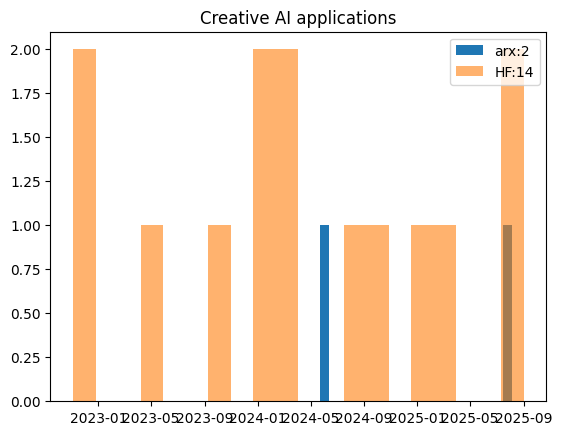

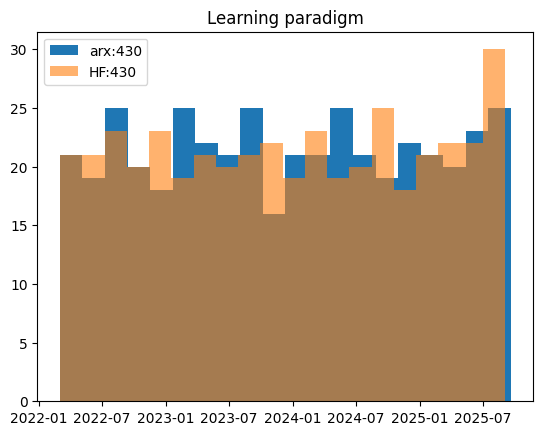

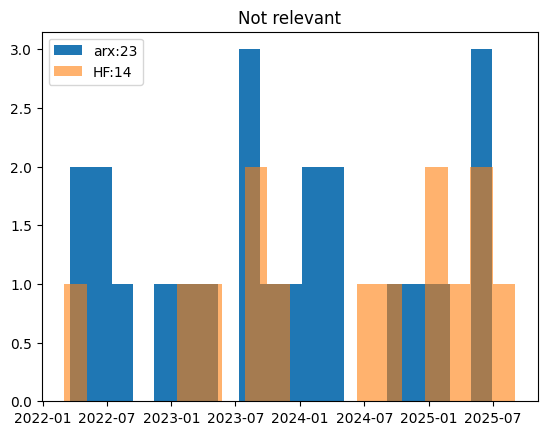

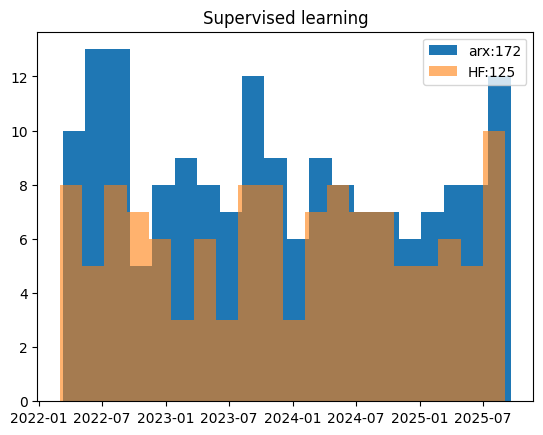

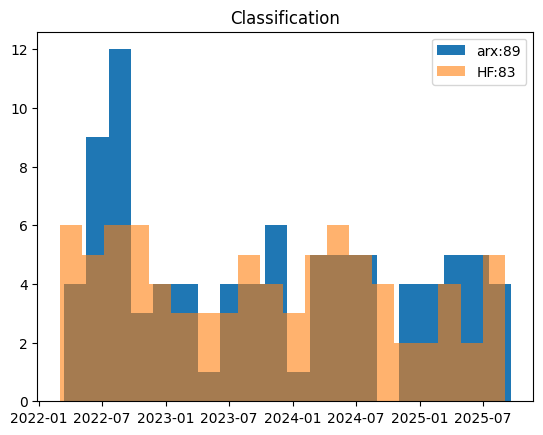

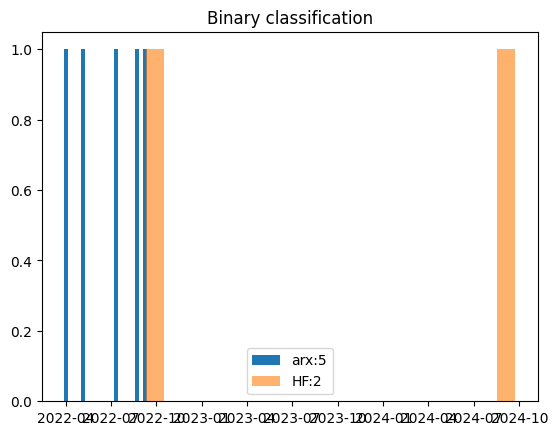

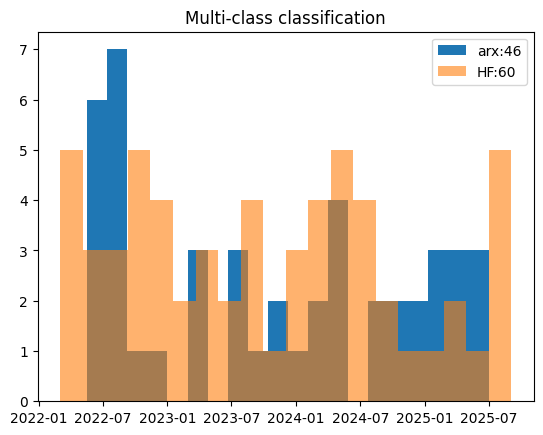

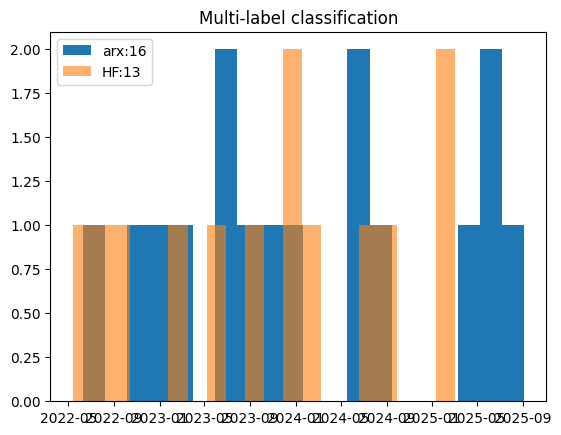

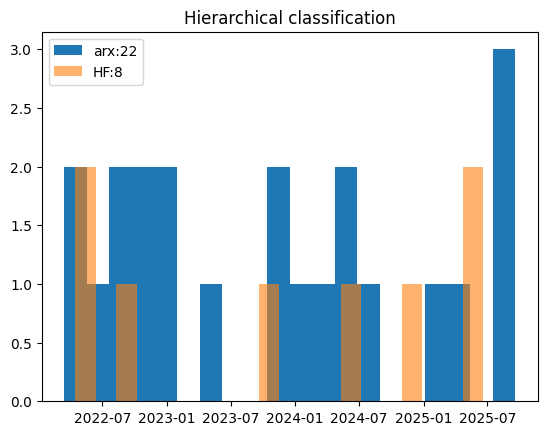

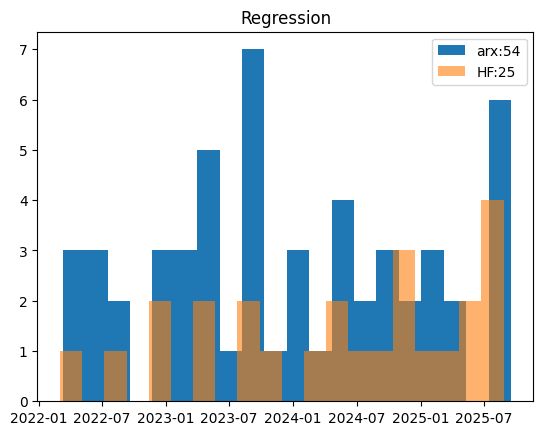

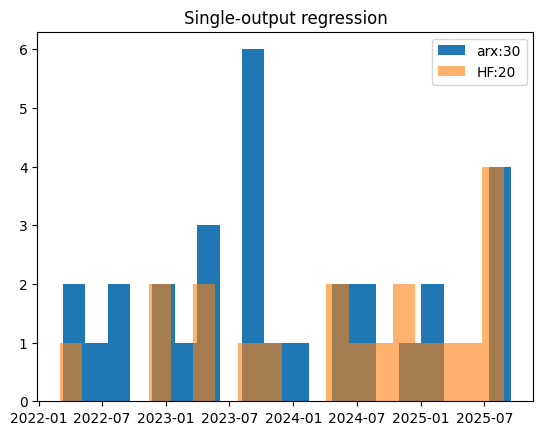

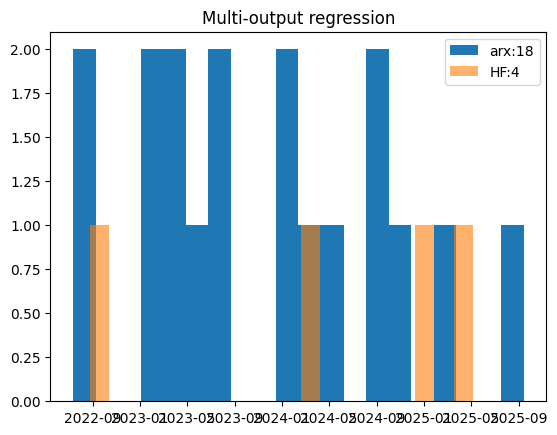

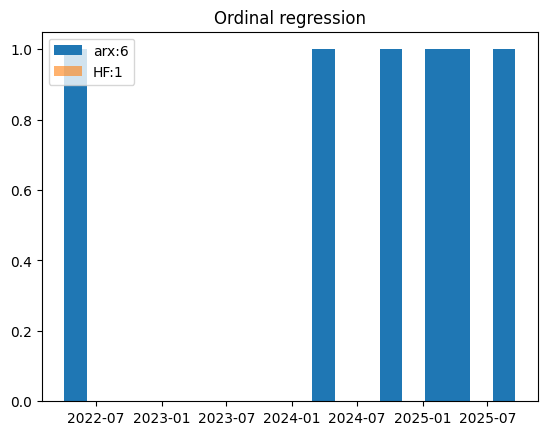

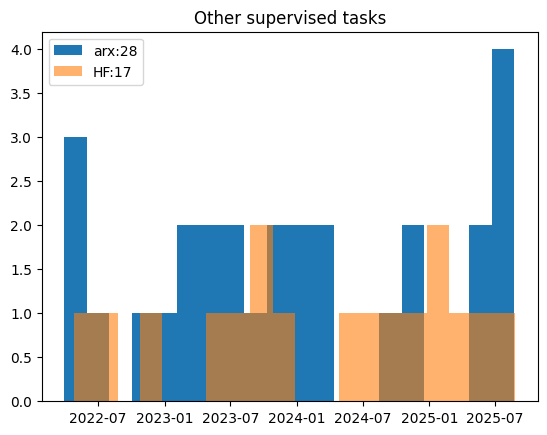

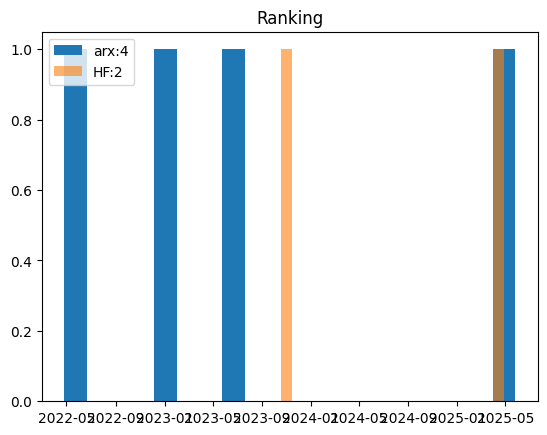

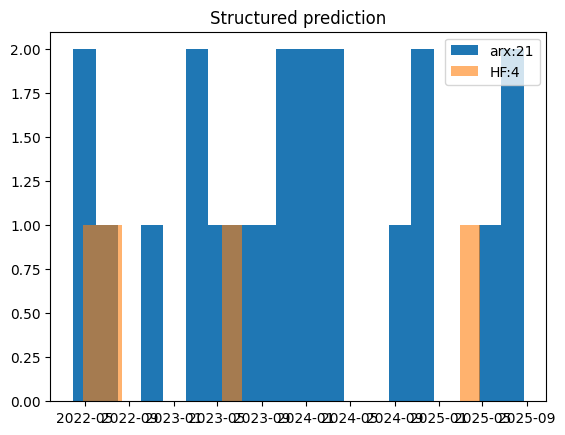

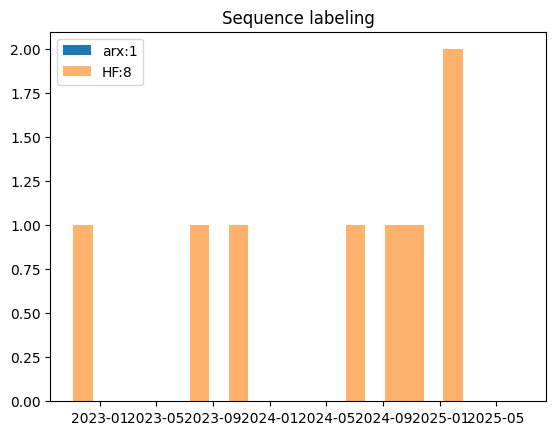

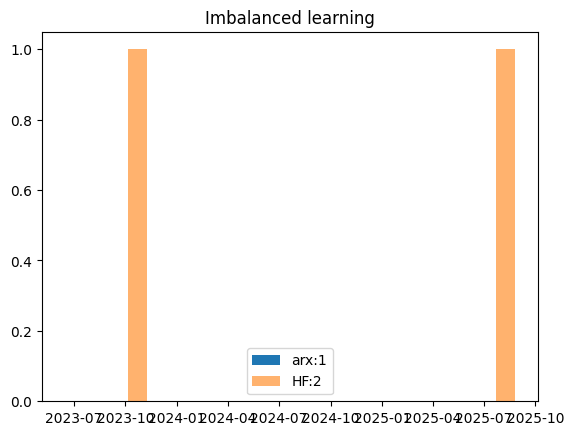

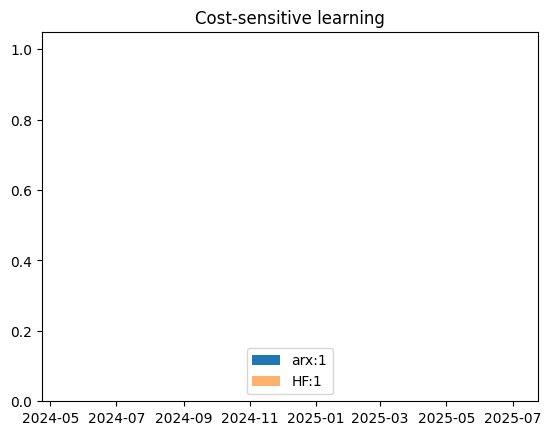

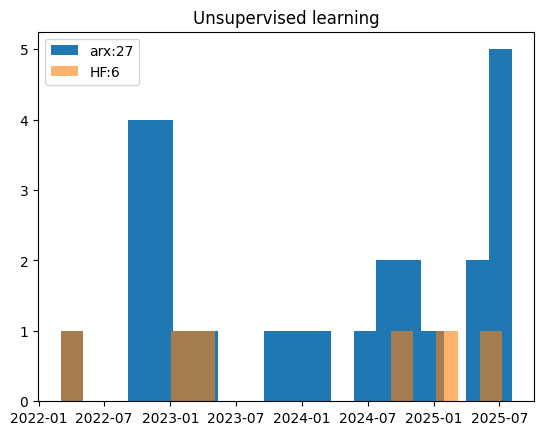

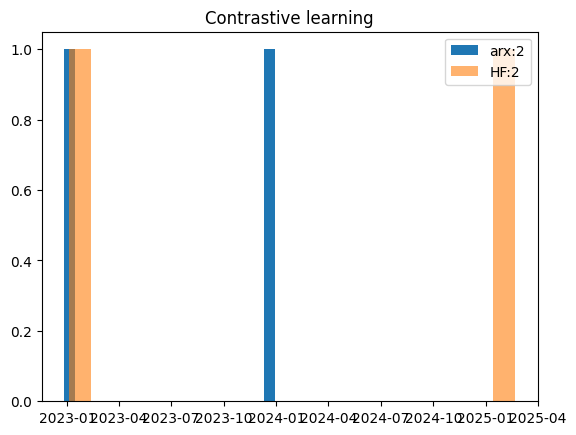

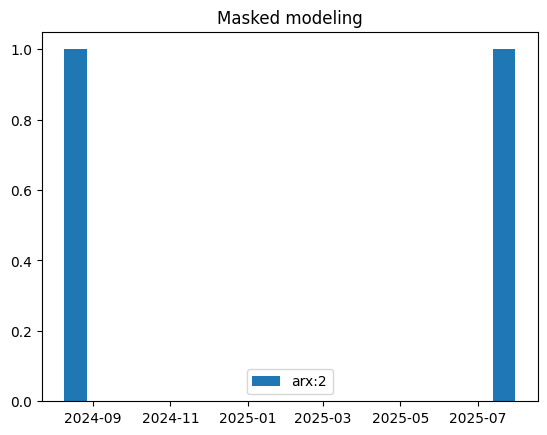

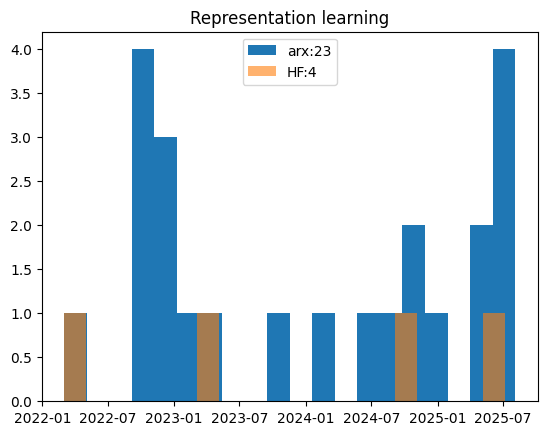

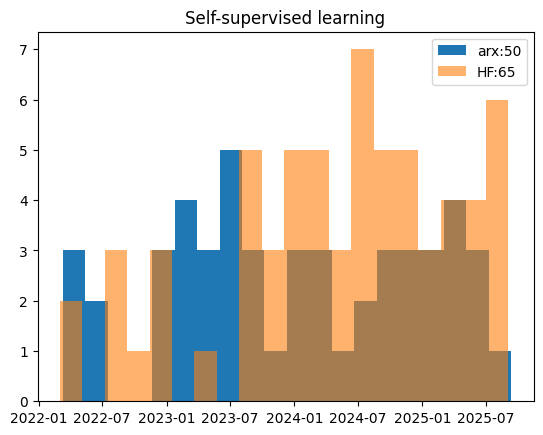

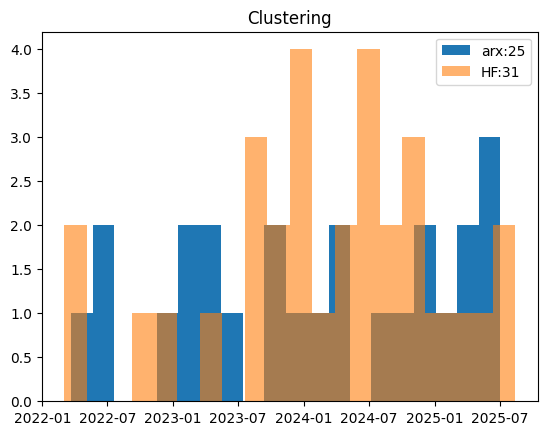

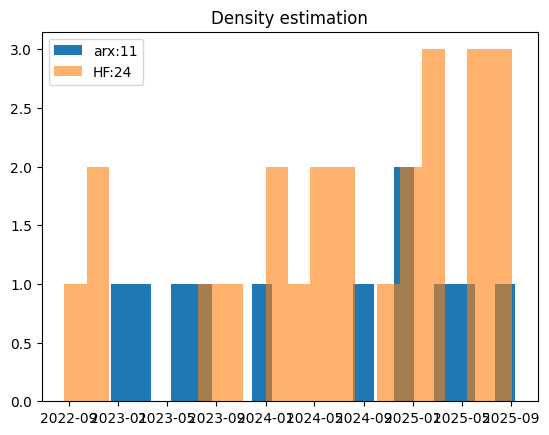

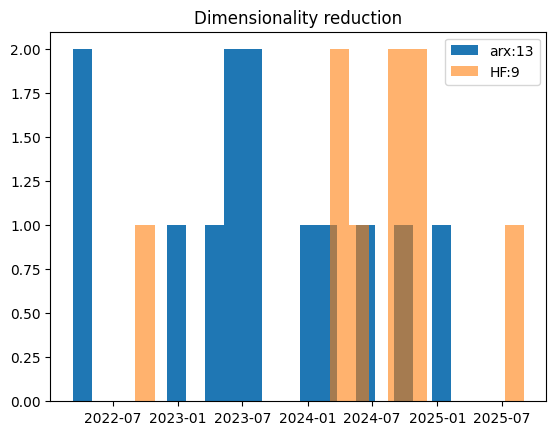

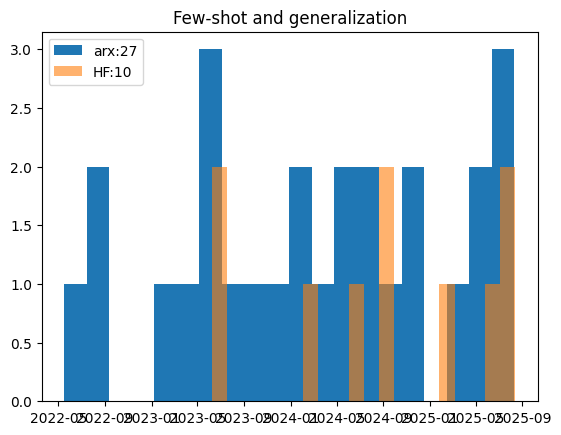

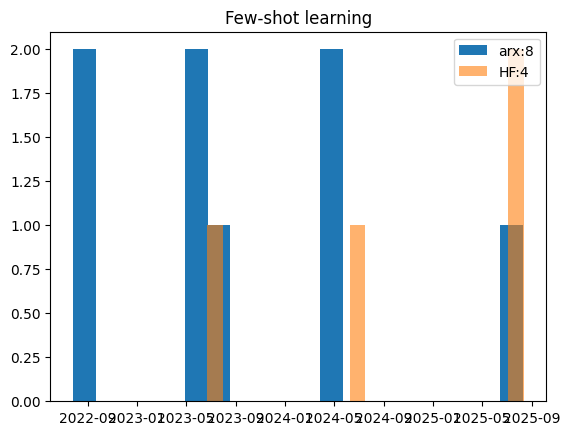

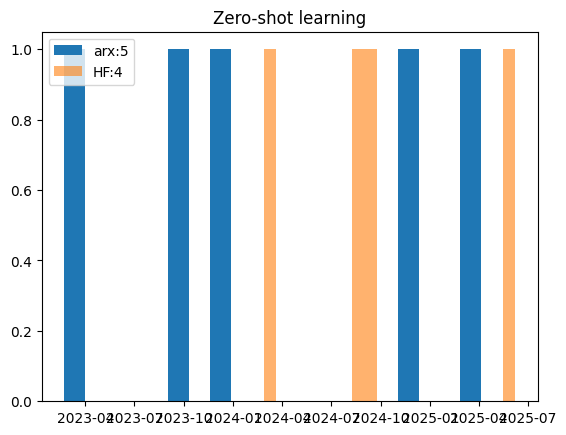

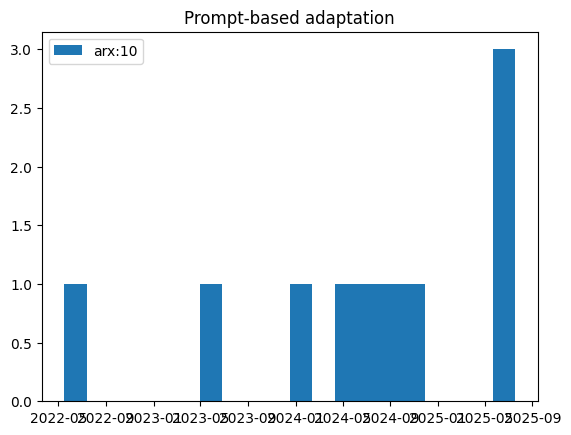

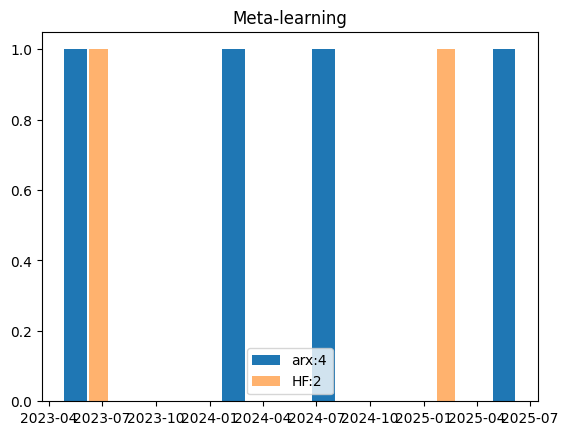

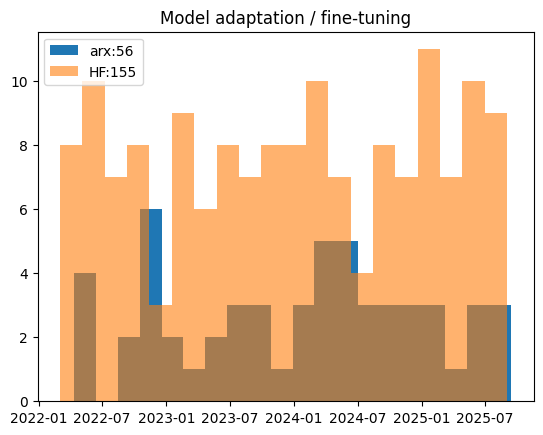

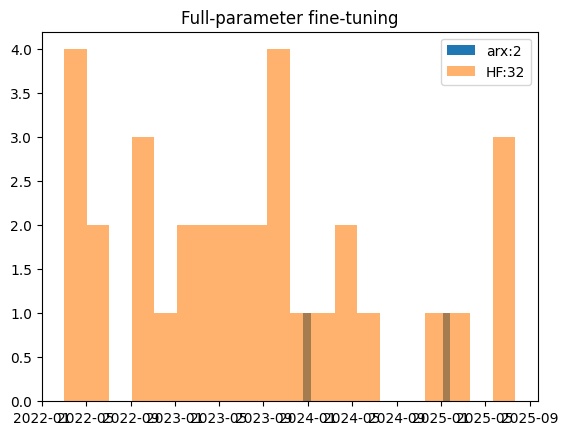

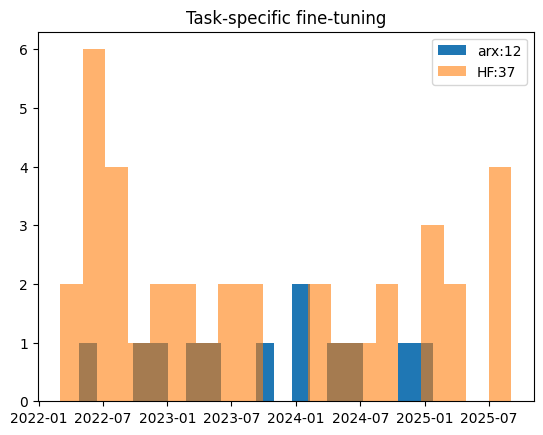

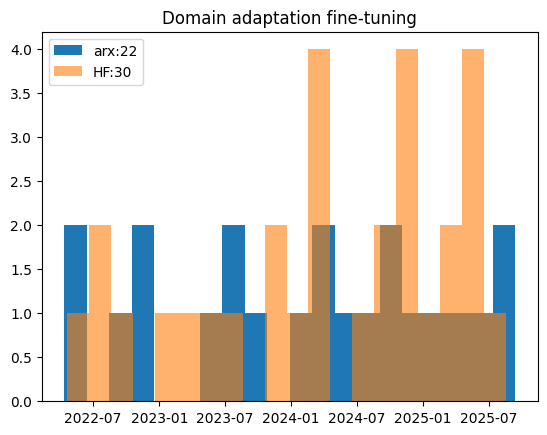

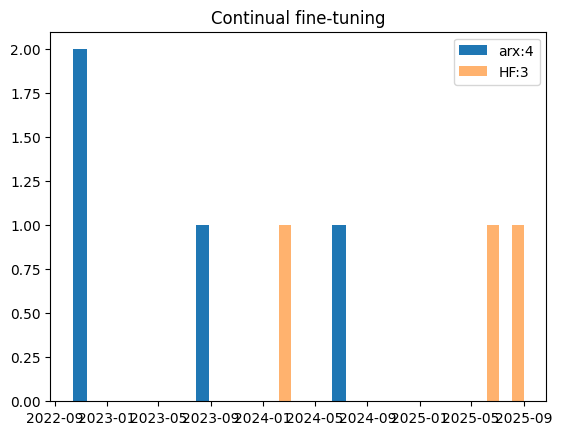

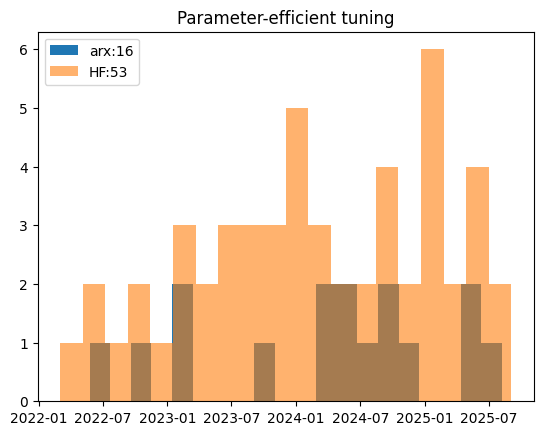

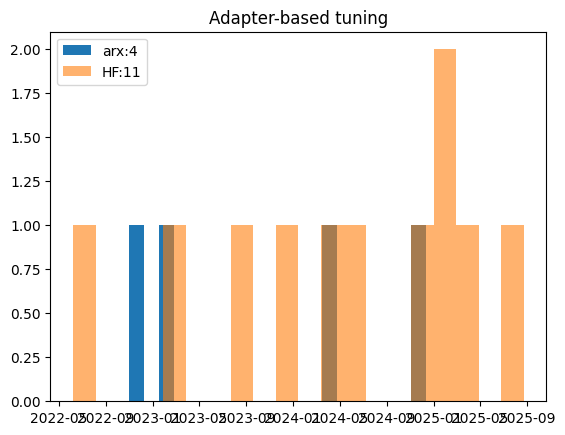

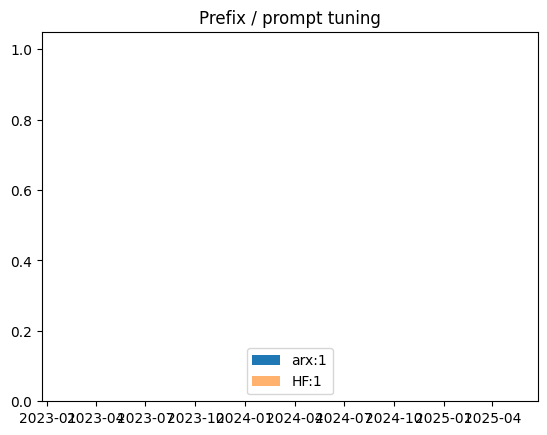

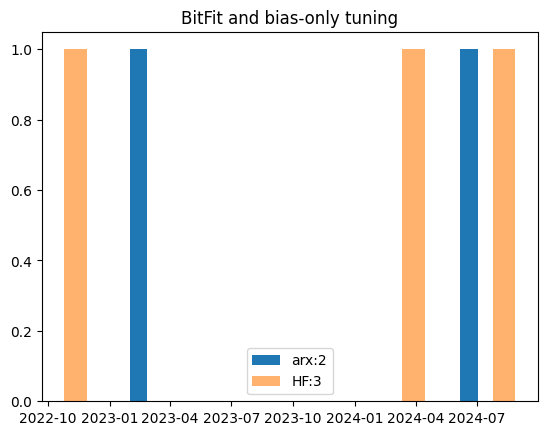

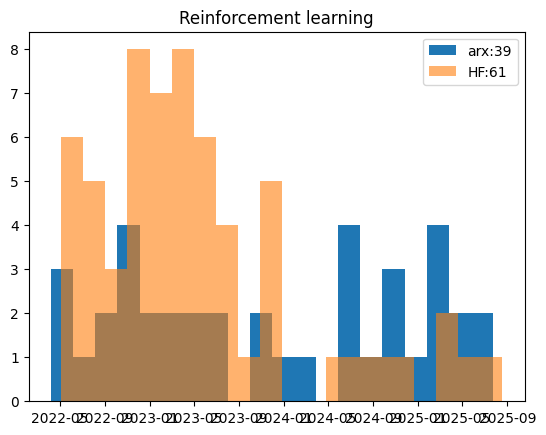

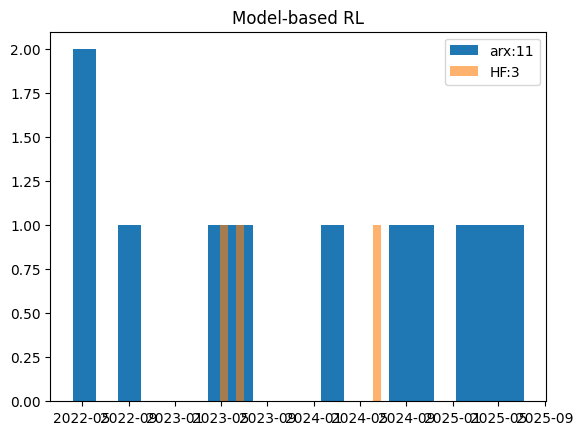

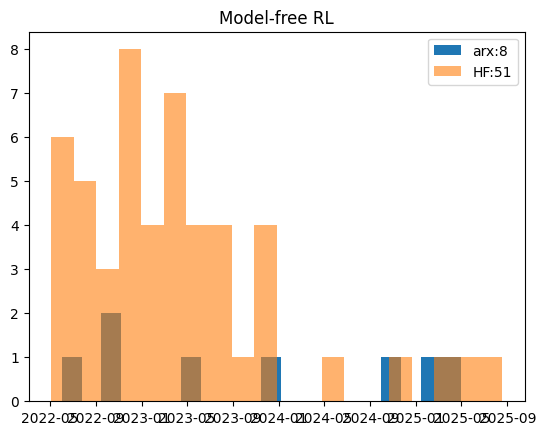

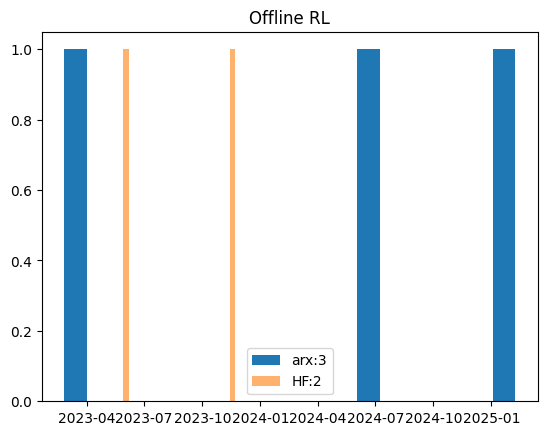

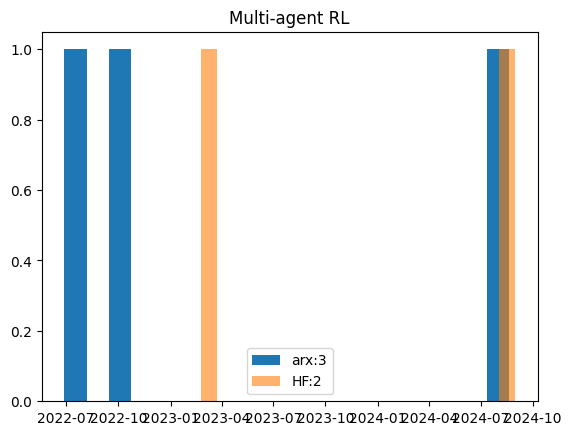

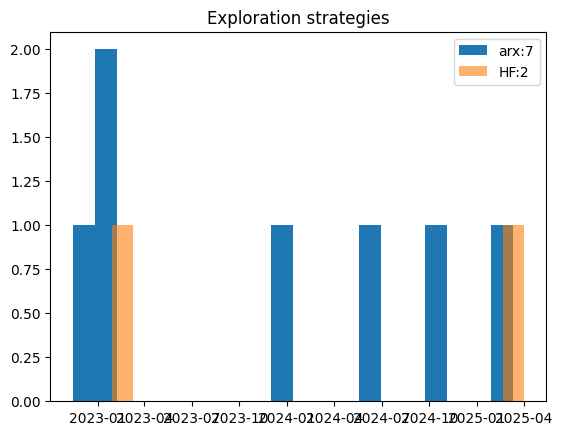

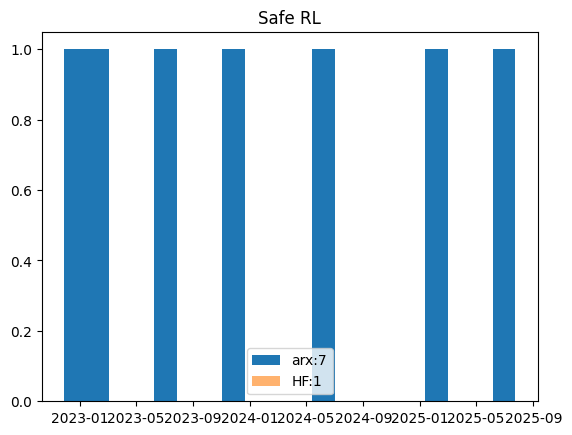

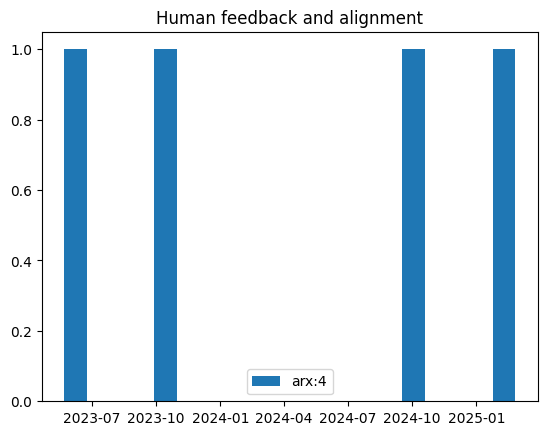

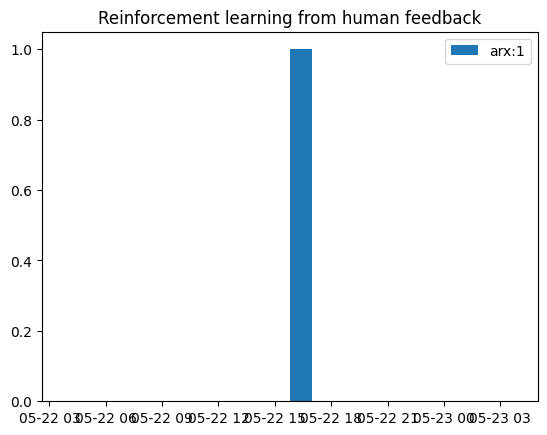

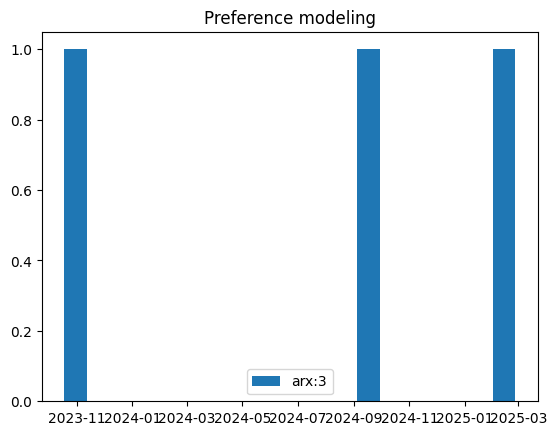

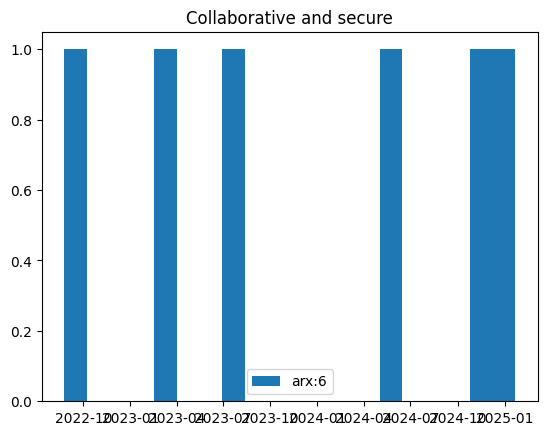

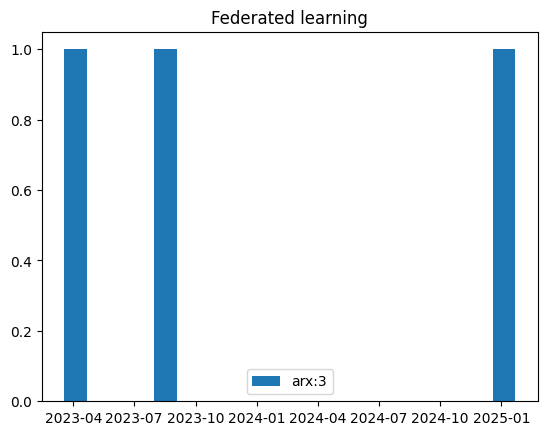

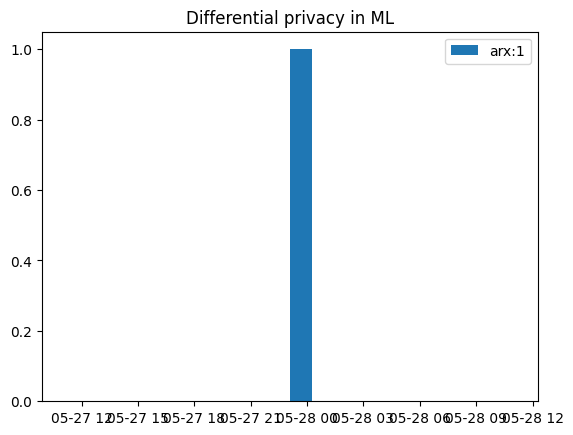

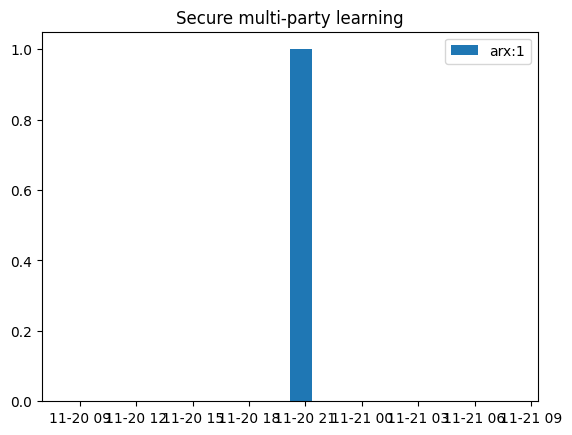

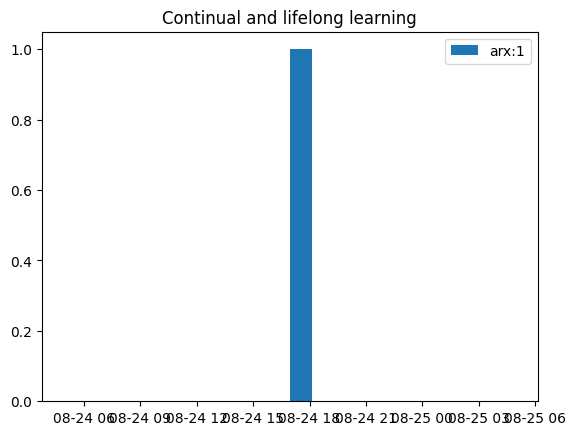

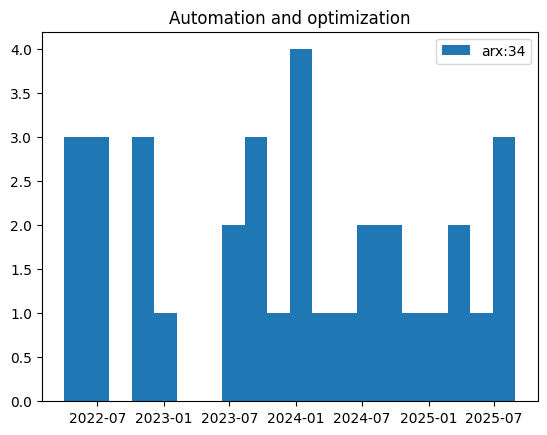

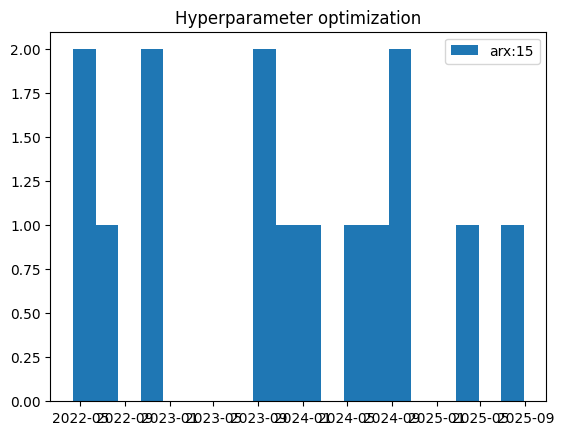

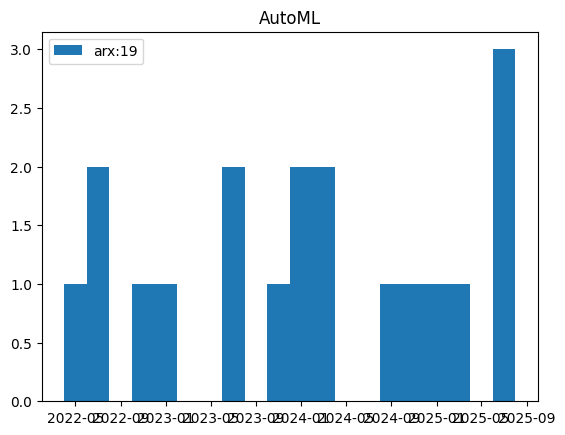

In [19]:
for term in ccs_strings:
    plot_term(term, 1)#, sigma=4, window=14)

In [10]:
len(ccs_strings)

169